# 台車モデルへ$\log$ バリア関数による制約を適用したC/GMRES

logバリア関数により、台車が通過できる位置と、台車を制御する入力に制約を実施した。

目標値は時変ではなく、一定の値で行っているが、ゲインを調整することで途中の軌道を与えなくても、目的の位置・姿勢に台車を制御することが出来る。

<img src="./images/simple_car1.gif" style="width:50%;" />
<img src="./images/simple_car2.gif" style="width:50%;" />
<img src="./images/simple_car3.gif" style="width:50%;" />
<img src="./images/simple_car4.gif" style="width:50%;" />

## 台車モデル

制御対象は以下の$x_1$方向にのみ速度$v$を持ち、$y_1$方向には速度を持たない台車とする。<br>
入力$u$は台車の前進方向$x_1$へ加速度を発生させ、入力$\tau$は台車の回転方向$\theta$に角加速度を発生させる。この二つが入力となる。

<img src="images/nonholonomic_car.png" style="width:40%;"/>

台車の前進方向の運動と、回転方向の運動を以下とする。

$$
\begin{aligned}
m \dot{v}(t) = u(t) \\
I \dot{\omega}(t) = \tau(t) \\
\dot{\theta}(t) = \omega(t)
\end{aligned}
$$

$v$を $\Sigma_o$ で表現すると、次のようになる。

$$
\begin{aligned}
\dot{x}(t)= v(t) \cos(\theta(t)) \\
\dot{y}(t) = v(t) \sin(\theta(t))
\end{aligned}
$$

状態 $X$ を次のように設定する。

$$
X = \begin{bmatrix} v(t) & \theta(t) & \omega(t) & x(t) & y(t) \end{bmatrix}^T
$$

よって、状態方程式 $\dot{X} = f(X, U, t)$ は次の式となる。

$$
\dot{X} = \begin{bmatrix}
\dot{v}(t) \\ \dot{\theta}(t) \\ \dot{\omega}(t) \\ \dot{x}(t) \\ \dot{y}(t)
\end{bmatrix} = 
\begin{bmatrix}
u(t)/m \\\omega(t) \\ \tau(t)/I \\ v(t) \cos(\theta(t)) \\ v(t) \sin(\theta(t))
\end{bmatrix}
$$

$$
U=\begin{bmatrix}
u(t) \\ \tau(t)
\end{bmatrix}
$$

#### 非ホロノミック拘束について

台車は $\Sigma_1$ の $y_1$ 方向には横滑りしないという条件がある。

$\Sigma_o$ における台車の速度 $^o v$ を以下のようにベクトルで$x,y$軸それぞれの速度として表現する。

$$
^o v = \begin{bmatrix} \dot{x} \\ \dot{y} \end{bmatrix}
$$

$\Sigma_1$ の$y_1$ 方向の単位ベクトルを$e_{y_1}$とすると、これを$\Sigma_o$ で表すと以下となる。

$$
^o e_{y_1} = \begin{bmatrix} -\sin(\theta) \\ \cos(\theta) \end{bmatrix}
$$

よって、台車の$y_1$方向の速度は内積によって、以下のように表すことが出来る。

$$
v_{y_1} = {^o e_{y_1}}^T \ ^o v = -\dot{x} \sin(\theta) + \dot{y} \cos(\theta)
$$

台車は横滑りしないため、$v_{y_1}=0$であり、これより以下の拘束条件が導かれる。

$$
-\dot{x} \sin(\theta) + \dot{y} \cos(\theta) = 0
$$

これを非ホロノミック拘束と呼ぶ。

拘束条件を以下のように位置、姿勢だけで記述できる場合、これをホロノミック拘束と呼ぶ。

$$
g(x, y, \theta) = 0
$$

今回の拘束条件は以下のように速度に対するものである。

$$
-\dot{x} \sin(\theta) + \dot{y} \cos(\theta) = 0
$$

これを一般的には積分してホロノミック拘束$g(x,y,\theta) = 0$ という位置だけの拘束にはできない。

これは、「横方向に速度を出すことはできないが、横にある位置へ移動することはできる」ということを意味している。

例えば台車の位置が$\Sigma_o$ で $(0,0)$ にあったとする。その後台車は左へ 90deg 旋回、1 前進、右へ90deg 旋回とすれば $(0,1)$ へ到達することが出来る。

よって、位置が拘束されているのではなく、瞬間的に許される速度方向が拘束されているということになる。

車体の前進方向の速度 $v$を$\Sigma_o$で表した方程式を上記の$v_{y_1}$ の式に代入すると以下のようになるため、状態方程式そのものが非ホロノミック拘束を常に満たしている。

$$
v_{y_1} = {^o e_{y_1}}^T \ ^o v = -\dot{x} \sin(\theta) + \dot{y} \cos(\theta) = -v \cos(\theta) \sin(\theta) + v \sin(\theta)\cos(\theta) = 0
$$

## 位置と制御入力の拘束

### 位置拘束

台車はXY平面を動く。そのため、ある範囲の中に入らないように位置の拘束を行う。

この範囲を以下の円の方程式から考える。

$$
(x - x_{c_1})^2 + (y - y_{c_1})^2 = {r_1}^2
$$

この方程式は、$(x_{c_1}, y_{c_1})$を中心に半径 $r_1$ の円である。

以下のように等式の拘束とすると、台車の位置 ($x,y$) は円周上に固定されることになる。

$$
(x - x_{c_1})^2 + (y - y_{c_1})^2 - {r_1}^2 = 0
$$

以下の方程式は、$(x_{c_1}, y_{c_1})$を中心に半径 $r_1$ の円の内側に台車の位置($x,y$)があることにある。これは範囲の外に出ないような拘束に繋がる。

$$
(x - x_{c_1})^2 + (y - y_{c_1})^2 \le {r_1}^2
$$

以下の方程式は、$(x_{c_1}, y_{c_1})$を中心に半径 $r_1$ の円の外側に台車の位置($x,y$)があることにある。これは範囲の中に入らないような拘束に繋がる。

$$
(x - x_{c_1})^2 + (y - y_{c_1})^2 > {r_1}^2
$$

ここから 位置拘束$G_1$を以下のように定義する。

$$
G_1 = (x - x_{c_1})^2 + (y - y_{c_1})^2 - {r_1}^2 > 0
$$

例えば簡単に($x_{c_1},  y_{c_1}$) = ($0,0$)、$r_1 = 1$ として考えると、以下のように円周に正方向から近づくと、$G_1$ は境界の $0$ に近づいていく。

- $(x,y) = (1.1, 0)$ : $G_1 = 1.21 - 1 = 0.21 > 0$
- $(x,y) = (1.001, 0)$ : $G_1 = 1.001^2 - 1 = 0.002001 > 0$

よって、$-\log(G_1)$とすると、境界に近づくにつれ $+\infty$ と壁を高くすることが出来る。これをランニングコストに追加する。

この考え方で、$G_i \ (i = 1, \cdots, m)$ のように複数の位置拘束を考えることが出来る。

今回は位置拘束は2つとする。

$$
\begin{aligned}
G_1 &= (x - x_{c_1})^2 + (y - y_{c_1})^2 - {r_1}^2 > 0 \\
G_2 &= (x - x_{c_2})^2 + (y - y_{c_2})^2 - {r_2}^2 > 0
\end{aligned}
$$

計算のため上記を正規化する。

$$
\begin{aligned}
G_1 &= \frac{(x - x_{c_1})^2 + (y - y_{c_1})^2}{{r_1}^2} - 1 > 0 \\
G_2 &= \frac{(x - x_{c_2})^2 + (y - y_{c_2})^2}{{r_2}^2} - 1 > 0
\end{aligned}
$$


例えば $x_{c_1}= 0, y_{c_1}=0, r_1 = 1$として$-\log(G_1)$を$x$の変化に対して描くと以下のように、壁から遠のくほど数値が低くなっていくため、最小化という観点では、その最適値は壁から無限大に離れたところとなる。そのため、目標値が与えらえたとしても、そこよりも遠くの位置でバランスを取るような挙動になる。図で描くと以下の状況である。


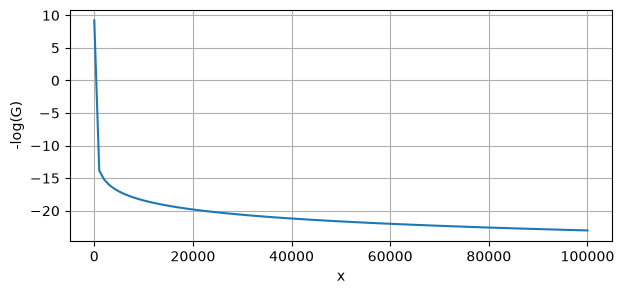

In [136]:
import matplotlib.pyplot as plt
import numpy as np

r1 = 1
x_window = np.linspace(r1+1e-6, 1e5, 100)
G = lambda x : x**2 / 1 - 1
y = -np.log(np.clip(G(x_window), 0.0001, None))
plt.figure(figsize=(7,3))
plt.plot(x_window, y)
plt.grid()
plt.xlabel("x")
plt.ylabel("-log(G)")
plt.show()


そこで、以下のように構成を変更する。

これにより、$(x - x_{c_1})^2 + (y - y_{c_1})^2 \rightarrow r_1^2$ と境界に近づくと $G_1 \rightarrow +0$ となり、$-\log(G_1) \rightarrow +\infty$ となる。また、$(x - x_{c_1})^2 + (y - y_{c_1})^2 \rightarrow \infty$ となると、$G_1 \rightarrow 1$ となるため、$-\log(G_1) \rightarrow +0$ となる。 

$$
\begin{aligned}
G_1 &= 1 - \frac{{r_1}^2}{(x - x_{c_1})^2 + (y - y_{c_1})^2} > 0 \\
G_2 &= 1 - \frac{{r_2}^2}{(x - x_{c_2})^2 + (y - y_{c_2})^2} > 0
\end{aligned}
$$

上記と同じく図を描くと以下のようになる。ある値を境に$-\log(G)$は急速に小さくなり、距離が無限大へ近づくと0へ漸近する。

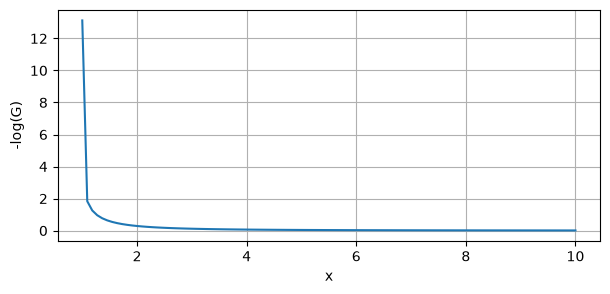

In [137]:
x_window = np.linspace(r1+1e-6, 10, 100)
G = lambda x : 1 - 1/ x**2
y = -np.log(G(x_window))
plt.figure(figsize=(7,3))
plt.plot(x_window, y)
plt.grid()
plt.xlabel("x")
plt.ylabel("-log(G)")
plt.show()


### 制御入力拘束

入力として $u, \tau$ の二つがある。そこで次のように上限値を設ける。

$$
\begin{split}
\begin{aligned}
u^2 &\le {u_{max}}^2 \\
\tau^2 & \le {\tau_{max}}^2
\end{aligned}
\end{split}
$$

$\log$関数の特徴に合わせるように、次のように 正側の拘束に変換する。

$$
\begin{split}
\begin{aligned}
u^2 - {u_{max}}^2&\le 0  \\
\tau^2 - {\tau_{max}}^2 & \le 0 
\end{aligned}
\end{split} \Rightarrow
\begin{split}
\begin{aligned}
{u_{max}}^2 - u^2 &\ge 0  \\
{\tau_{max}}^2 - \tau^2 & \ge 0 
\end{aligned}
\end{split}
$$

それぞれを以下の拘束とする。

$$
\begin{aligned}
G_u &= {u_{max}}^2 - u^2 > 0\\
G_\tau &= {\tau_{max}}^2 - \tau^2 > 0
\end{aligned}
$$

また、こちらも計算のため、以下のように正規化を行う。

$$
\begin{aligned}
G_u &= 1 - \left(\frac{u}{u_{max}}\right)^2 > 0\\
G_\tau &= 1 - \left(\frac{\tau}{\tau_{max}}\right)^2 > 0
\end{aligned}
$$

この構成は位置拘束と同じ形式であるため、$u \rightarrow 0$ になると、$-\log(G_u) \rightarrow 0$ となる。

$\log$関数による制御入力拘束は以下となる。

$$
-\log(G_u) , \space -\log(G_\tau)
$$

位置と制御入力の拘束条件をまとめて、以下のように記述する。

$$
G(X,U) = \begin{bmatrix}
G_1 , G_2 , G_u, G_\tau
\end{bmatrix}^T
$$


## 拡大評価関数と各コスト関数


$\log$バリア関数を制約条件に追加した拡大評価関数 $\bar{J}$ は次となる。

$$
\bar{J} = \Phi(X(T)) + \int_0^T \left[ L(X,U,t) - \eta^T \log(G(X,U)) + \lambda^T \left( f(X,U,t) - \dot{X} \right) \right] dt
$$

ここで$\lambda$は状態$X$に合わせて以下のようにする。

$$
\lambda = \begin{bmatrix}
\lambda_v , \lambda_\theta , \lambda_\omega ,\lambda_x, \lambda_y
\end{bmatrix}^T
$$

また、$\eta$は制約に合わせて以下のようにする。今回位置の制約は二つとする。また、この$\eta$は$\log$バリア関数に対応する重みである。

$$
\eta = \begin{bmatrix}
\eta_1 , \eta_2, \eta_u, \eta_\tau
\end{bmatrix}^T
$$

また、表現として$\log(G(X,U))$は以下のようになっているとする。

$$
\log(G(X,U)) = \begin{bmatrix}
\log(G_1) \\
\log(G_2) \\
\log(G_u) \\
\log(G_\tau)
\end{bmatrix}
$$

### 終端コスト $\Phi$

終端の角度目標値との誤差の表現について注意が必要である。

$e = (\theta(T) - \theta_{ref})$とすると、$\theta(T)$が178degから先 3deg に進んで-179degとなった場合、$e$は不連続な値となる。

|e|$\theta(T)$|$\theta_{ref}$|
|---:|---:|---:|
|-1|178|179|
|-358|-179|179|
|-349|-170|179|

そこで、$\cos(e)$とすると、その値を[-1,1]の範囲に収めることが出来る。
最小化問題であるため、$\cos(e) = -1$ が最小値、つまり$e=\pm\pi$と目標とは反対の向きが最小になってしまう。

そこで $1-\cos(e)$とする。すると以下のように、$\theta(T)$が$\theta_{ref}$に近いときはゼロに近く、反転しているときは2 、90deg離れているときは1となり、目標値に近い姿勢を最小とすることができる。

|$1-\cos(e)$|e|$\theta(T)$|$\theta_{ref}$|
|---:|---:|---:|---:|
|0.00015|-1|178|179|
|0.00061|-358|-179|179|
|2|-180|-1|179|
|1|-90|89|179|

よって、終端コストは以下のようになる。

$$
\boxed{
\begin{aligned}
\Phi(X(T)) = \frac{1}{2} \Big[ q_{v_T} \ (v(T))^2 +  q_{\omega_T}(\omega(T))^2 \Big] + q_{\theta_T} \ \left(1 - \cos(\theta(T) - \theta_{ref})\right) \\ 
+ \frac{1}{2} \Big[ q_{x_T}(x(T) - x_{ref})^2 + q_{y_T}(y(T) - y_{ref})^2 \Big]
\end{aligned}
}
$$ 

最小化問題に対するコストであるため、それぞれのゲインに関して以下の目的になる。

- $q_{v_T}$ : 最終時刻$T$における速度 $v(T)$ を小さくする
- $q_{\omega_T}$ : 最終時刻$T$における角速度 $\omega(T)$ を小さくする
- $q_{\theta_T}$ : 最終時刻$T$における角度の誤差 $(\theta(T)-\theta_{ref}) $ を小さくする
- $q_{x_T}$ : 最終時刻$T$における$x$位置の誤差 $(x(T)-x_{ref}) $ を小さくする
- $q_{y_T}$ : 最終時刻$T$における$y$位置の誤差 $(y(T)-y_{ref}) $ を小さくする


### ランニングコスト $L$

ランニングコストにおける角度目標値との誤差も終端コストで用いた表現と同じものを用いる。

$$
\boxed{
\begin{aligned}
L(X,U,t) = \frac{1}{2} \left( q_v (v(t))^2 + q_{\omega}(\omega(t))^2 \right) + q_{\theta} \left(1-\cos(\theta(t) - \theta_{ref}) \right) \\
+ \frac{1}{2} \Big(q_x(x(t) - x_{ref})^2 + q_y(y(t) - y_{ref})^2  + q_u (u(t))^2 + q_\tau (\tau(t))^2 \Big) 
\end{aligned}
}
$$

最小化問題に対するコストであるため、それぞれのゲインに関して以下の目的になる。

- $q_{v}$ : 区間$[0,T)$における速度 $v(t)$ を小さくする
- $q_{\omega}$ : 区間$[0,T)$における角速度 $\omega(t)$ を小さくする
- $q_{\theta}$ : 区間$[0,T)$における角度の誤差 $(\theta(t)-\theta_{ref}) $ を小さくする
- $q_{x}$ : 区間$[0,T)$における$x$位置の誤差 $(x(t)-x_{ref}) $ を小さくする
- $q_{y}$ : 区間$[0,T)$における$y位置$の誤差 $(y(t)-y_{ref}) $ を小さくする
- $q_{u}$ : 区間$[0,T)$における入力 $u(t)$ を小さくする
- $q_{\tau}$ : 区間$[0,T)$における入力$\tau(t)$ を小さくする


#### $\log$バリア関数によるコスト $-\eta^T \ \log(G)$の項

$$
\boxed{
\begin{aligned}
-\eta^T \log(G(x,u)) &= -\eta_1 \log \left(1 - \frac{{r_1}^2}{(x(t) - x_{c_1})^2 + (y(t) - y_{c_1})^2} \right) 
- \eta_2 \log \left(1-  \frac{{r_2}^2}{(x(t) - x_{c_2})^2 + (y(t) - y_{c_2})^2} \right) \\
&- \eta_u \log \left( 1 - \left(\frac{u(t)}{{u_{max}}}\right)^2 \right) 
- \eta_\tau \log \left( 1 - \left(\frac{\tau(t)}{{\tau_{max}}} \right)^2 \right) \\
\end{aligned}
}
$$

$\eta$はゲインとして取り扱う。そのため、$\eta=0$とすると、この拘束自体を評価から除外することが可能になっている。

評価関数では $-\eta^T \log(G(x,u))$ で評価を行うため、境界から離れるほどコストは小さくなっていく。
また、境界に近づくほど $+\infty$ となるため、境界へ近づかないような挙動になる。

### Hamiltonianの構成

$H$ は以下のように $\log$バリア関数を追加した形になる。

$$
H = L - \eta^T \log(G) + f^T \lambda
$$

$f^T \lambda$の項は以下である。

$$
\boxed{
f^T \lambda = \lambda_v u(t)/m + \lambda_\theta \omega(t) + \lambda_\omega \tau(t)/I + \lambda_x v(t) \cos(\theta(t)) + \lambda_y v(t) \sin(\theta(t))
}
$$

これを$X, U, \lambda$ で偏微分を行う。

#### $X$による偏微分

$$
X = \begin{bmatrix} v(t) & \theta(t) & \omega(t) & x(t) & y(t) \end{bmatrix}^T
$$


$$
H_X = \frac{\partial H}{\partial X} =
\begin{bmatrix}
{\partial H}/{\partial v} \\ {\partial H}/{\partial \theta} \\ {\partial H}/{\partial \omega} \\ {\partial H}/{\partial x} \\ {\partial H}/{\partial y}
\end{bmatrix} \\
$$

$$
\boxed{
\begin{array}{l}
\dfrac{\partial H}{\partial v} = q_v v(t) + \lambda_x \cos(\theta(t)) + \lambda_y \sin(\theta(t)) \\[8pt]
\dfrac{\partial H}{\partial \theta} = q_\theta (\sin(\theta(t) - \theta_{ref}) ) - \lambda_x v(t)\sin(\theta(t)) + \lambda_y v(t) \cos(\theta(t)) \\[8pt]
\dfrac{\partial H}{\partial \omega} = q_\omega \omega(t) + \lambda_\theta \\[8pt] 
\begin{aligned}
\frac{\partial H}{\partial x} =
q_x(x(t) - x_{ref}) - \sum_{i=1}^2 \eta_i \dfrac{2 r_i^2 (x(t) - x_{c_i})}{\left( (x(t) - x_{c_i})^2 + (y(t) - y_{c_i})^2 \right)^2} \left(1 - \frac{r_i^2}{(x(t) - x_{c_i})^2 + (y(t) - y_{c_i})^2} \right)^{-1}
\end{aligned} \\
\begin{aligned}
\frac{\partial H}{\partial y} =
q_y(y(t) - y_{ref}) - \sum_{i=1}^2 \eta_i \dfrac{2 r_i^2 (y(t) - y_{c_i})}{\left( (x(t) - x_{c_i})^2 + (y(t) - y_{c_i})^2 \right)^2} \left(1 - \frac{r_i^2}{(x(t) - x_{c_i})^2 + (y(t) - y_{c_i})^2} \right)^{-1} 
\end{aligned}
\end{array}
}
$$

#### $U$ による偏微分

$$
U = \begin{bmatrix} u(t) & \tau(t) \end{bmatrix}^T
$$

$$
H_U = \frac{\partial H}{\partial U} =\begin{bmatrix} \partial H / \partial u \\ \partial H / \partial \tau \end{bmatrix}
$$

$$
\boxed{
\begin{array}{l}
\dfrac{\partial H}{\partial u} = q_u u(t) + 2\eta_u \left( \dfrac{u(t)}{{u_{max}}^2}\right)\left( 1 - \left( \dfrac{u(t)}{u_{max}}\right)^2\right)^{-1} + \dfrac{\lambda_v}{m} \\
\dfrac{\partial H}{\partial \tau} = q_\tau \tau(t) + 2\eta_\tau \left( \dfrac{\tau(t)}{{\tau_{max}}^2}\right)\left( 1 - \left( \dfrac{\tau(t)}{\tau_{max}}\right)^2\right)^{-1} + \dfrac{\lambda_\omega}{I} \\
\end{array}
}
$$

### $\lambda$ による偏微分

$H_\lambda = \dfrac{\partial H}{\partial \lambda} = f(X,U,t)$より、

$$
\boxed{
H_\lambda = \begin{bmatrix}
u(t)/m \\\omega(t) \\ \tau(t)/I \\ v(t) \cos(\theta(t)) \\ v(t) \sin(\theta(t))
\end{bmatrix}
}
$$

#### 終端条件 $\Phi_X$

$$
\Phi_X(X(T)) = \frac{\partial \Phi(X(T))}{\partial X(T)} =
\begin{bmatrix}
\partial \Phi(X(T)) / \partial v(T) \\
\partial \Phi(X(T)) / \partial \theta(T) \\
\partial \Phi(X(T)) / \partial \omega(T) \\
\partial \Phi(X(T)) / \partial x(T) \\
\partial \Phi(X(T)) / \partial y(T) \\
\end{bmatrix}
$$

$$
\boxed{
\begin{array}{l}
\dfrac{\partial \Phi(X(T))}{\partial v(T)} = q_{v_T} v(T) \\[8pt]
\dfrac{\partial \Phi(X(T))}{\partial \theta(T)} = q_{\theta_T}\sin(\theta(T) - \theta_{ref}) \\[8pt]
\dfrac{\partial \Phi(X(T))}{\partial \omega(T)} = q_{\omega_T} \omega(T) \\[8pt]
\dfrac{\partial \Phi(X(T))}{\partial x(T)} = q_{x_T} (x(T) -x_{ref}) \\[8pt]
\dfrac{\partial \Phi(X(T))}{\partial y(T)} = q_{y_T} (y(T) - y_{ref}) \\[8pt]
\end{array}
}
$$


## PMPの必要条件式

状態方程式、終端条件、随伴方程式、停留条件は以下となる。

$$
\boxed{
\begin{aligned}
\dot{X} &= H_\lambda \\
\lambda(T) &= \Phi_X(X(T)) \\
\dot{\lambda} &= - H_X \\
H_U &= 0
\end{aligned}
}
$$

## C/GMRESでの計算



### 停留条件式 $F$の計算

実時刻$t_k$において予測ホライゾンを$N$分割し、予測ホライゾン内の離散時刻を$s_n$とする。制御入力列$\mathcal{U}(t_k)$を用いて各$s_n$における状態$X[n]$と随伴変数$\lambda[n]$を計算し、停留条件$F(\mathcal{U}(t_k),X(t_k),t_k)$を構成する。

予測ホライゾンを開始する時刻を$t_k$とする。予測ホライゾンの長さは以下のように、$T(t_0)=0$であり、時刻が進むにつれ$T(t_k) \rightarrow T_f$ へ収束していく。

$$
T(t_k) = T_f (1 -\exp(-\alpha t_k))
$$

離散時間のステップ幅 $h(t_k)$ は、予測ホライゾンの分割数を $N$ とすると、以下のように時変となる。

$$
h(t_k) = \frac{T(t_k)}{N}
$$

離散時刻 $s_n$は以下となる。

$$
s_n = n h(t_k), \quad n=0, \cdots , N
$$

時刻$t_k$における予測ホライゾンの各時刻 $s_n$ における制御入力を$U_n$とする。

$$
U_n(t_k) = \begin{bmatrix} u_n(t_k) \\ \tau_n(t_k) \end{bmatrix} \in \mathbb{R}^2
$$

これを用いて制御入力列 $\mathcal{U}(t_k)$を以下の構成とする。

$$
\mathcal{U}(t_k) = \begin{bmatrix}U_0(t_k) \\ U_1(t_k) \\ \vdots \\ U_{N-1}(t_k) \end{bmatrix} \in \mathbb{R}^{2N} 
$$

$t_k$における状態$X(t_k)$を時系列の初期値 $X[0]=X(t_k)$として、時系列を次のように求める。

$$
\begin{aligned}
X[n+1] &= X[n] + h(t_k) H_\lambda(X[n], U_n(t_k)) \\
\begin{bmatrix}
v[n+1] \\ \theta[n+1] \\ \omega[n+1] \\ x[n+1] \\ y[n+1]
\end{bmatrix}&=\begin{bmatrix}
v[n] \\ \theta[n] \\ \omega[n] \\ x[n] \\ y[n]
\end{bmatrix}
+ h(t_k) 
\begin{bmatrix}
u_n(t_k)/m \\\omega[n] \\ \tau_n(t_k)/I \\ v[n] \cos(\theta[n]) \\ v[n] \sin(\theta[n])
\end{bmatrix} , \quad n = 0, \cdots , N-1
\end{aligned} 
$$

終端条件を求めた$X[N]$より次のように求める。

$$
\begin{aligned}
\lambda[N] &= \Phi_X(X[N]) \\
\begin{bmatrix}
\lambda_v[N] \\ \lambda_\theta[N] \\ \lambda_\omega[N] \\ \lambda_x[N] \\ \lambda_y[N]
\end{bmatrix} &=
\begin{bmatrix}
q_{v_T} v[N] \\
q_{\theta_T} \sin(\theta[N] - \theta_{ref}) \\
q_{\omega_T} \omega[N] \\
q_{x_T} (x[N] - x_{ref}) \\
q_{y_T} (y[N] - y_{ref})
\end{bmatrix}
\end{aligned}
$$

随伴変数の時系列を求めた$\lambda[N]$より次のように求める。

$$
\begin{aligned}
\lambda[n] &= \lambda[n+1] + h(t_k) H_X (X[n], U_n(t_k), \lambda[n+1])\\ 
\begin{bmatrix}
\lambda_v[n] \\ \lambda_\theta[n] \\ \lambda_\omega[n] \\ \lambda_x[n] \\ \lambda_y[n]
\end{bmatrix} &=
\begin{bmatrix}
\lambda_v[n+1] \\ \lambda_\theta[n+1] \\ \lambda_\omega[n+1] \\ \lambda_x[n+1] \\ \lambda_y[n+1]
\end{bmatrix} + h(t_k)
\begin{bmatrix}
q_v v[n] + \lambda_x[n+1] \cos(\theta[n]) + \lambda_y[n+1] \sin(\theta[n]) \\[8pt]
q_\theta (\sin(\theta[n] - \theta_{ref}) ) - \lambda_x[n+1] v[n]\sin(\theta[n]) + \lambda_y[n+1] v[n] \cos(\theta[n]) \\[8pt]
q_\omega \omega[n] + \lambda_\theta[n+1] \\[8pt] 
\begin{aligned}
q_x(x[n] - x_{ref}) - \sum_{i=1}^2 \eta_i \dfrac{2 r_i^2 (x[n] - x_{c_i})}{\left( (x[n] - x_{c_i})^2 + (y[n] - y_{c_i})^2 \right)^2} \left(1 - \frac{r_i^2}{(x[n] - x_{c_i})^2 + (y[n] - y_{c_i})^2} \right)^{-1}
\end{aligned} \\
\begin{aligned}
q_y(y[n] - y_{ref}) - \sum_{i=1}^2 \eta_i \dfrac{2 r_i^2 (y[n] - y_{c_i})}{\left( (x[n] - x_{c_i})^2 + (y[n] - y_{c_i})^2 \right)^2} \left(1 - \frac{r_i^2}{(x[n] - x_{c_i})^2 + (y[n] - y_{c_i})^2} \right)^{-1} 
\end{aligned}
\end{bmatrix}
\end{aligned} , \quad n = N-1 , \cdots 1
$$

計算した状態$X$と随伴変数$\lambda$の時系列、制御入力列$\mathcal{U}(t_k)$を用いて、停留条件 $F(\mathcal{U}(t_k), X(t_k), t_k)$を次のように構成する。

$$
\begin{aligned}
F(\mathcal{U}(t_k), X(t_k), t_k) &= \begin{bmatrix} H_U(s_0) \\ \vdots \\ H_U(s_{N-1})\end{bmatrix}
&= \begin{bmatrix}
q_u u_0(t_k) + 2\eta_u \left( \dfrac{u_0(t_k)}{{u_{max}}^2}\right)\left( 1 - \left( \dfrac{u_0(t_k)}{u_{max}}\right)^2\right)^{-1} + \dfrac{\lambda_v[1]}{m} \\
q_\tau \tau_0(t_k) + 2\eta_\tau \left( \dfrac{\tau_0(t_k)}{{\tau_{max}}^2}\right)\left( 1 - \left( \dfrac{\tau_0(t_k)}{\tau_{max}}\right)^2\right)^{-1} + \dfrac{\lambda_\omega[1]}{I} \\
\vdots \\
q_u u_{N-1}(t_k) + 2\eta_u \left( \dfrac{u_{N-1}(t_k)}{{u_{max}}^2}\right)\left( 1 - \left( \dfrac{u_{N-1}(t_k)}{u_{max}}\right)^2\right)^{-1} + \dfrac{\lambda_v[N]}{m} \\
q_\tau \tau_{N-1}(t_k) + 2\eta_\tau \left( \dfrac{\tau_{N-1}(t_k)}{{\tau_{max}}^2}\right)\left( 1 - \left( \dfrac{\tau_{N-1}(t_k)}{\tau_{max}}\right)^2\right)^{-1} + \dfrac{\lambda_\omega[N]}{I} \\
\end{bmatrix}
\end{aligned} \in \mathbb{R}^{2N}
$$

この停留条件式 $F$の計算は、C/GMRESを計算する過程で何度も行われる。そのため、この計算を関数として捉え、入力を予測ホライゾンの計算を始める実時間上の$t_k$、制御入力列$\mathcal{U}(t_k)$, $t_k$時の制御対象の状態 $X(t_k)$として、$F(\mathcal{U}(t_k), X(t_k), t_k)$ を計算する。 

C/GMRESではこの停留条件$F(\mathcal{U}(t_k), X(t_k), t_k)=0$ となる$\mathcal{U}(t_k)$ を実時刻が進むごとに求める。

### 初期 $U(0)$ の計算

初期時刻 $t_0=0$では、予測ホライゾンの長さゼロの1点へ収束した状態になる。

$$
X^\star[0] = X(0)
$$

$$
\lambda^\star[0] = \Phi_X(X(0))
$$

この1点において、停留条件$H_U(0)=0$となる$U(0) = [u(0), \tau(0)]^T$を求め、それを以下のように制御入力列として設定する。

$$
\mathcal{U}(t_0) = \begin{bmatrix} U(0) \\ \vdots \\ U(0) \end{bmatrix}\in \mathbb{R}^{2N}
$$

$H_U$を構成すると、以下のようになる。これをNewton-Raphson法で求める

$$
H_U =\begin{bmatrix}
H_U(u) \\ H_U(\tau)
\end{bmatrix}
=\begin{bmatrix}
q_u u(t) + 2\eta_u \left( \dfrac{u(t)}{{u_{max}}^2}\right)\left( 1 - \left( \dfrac{u(t)}{u_{max}}\right)^2\right)^{-1} + \dfrac{q_{v_T} v(0)}{m} \\
q_\tau \tau(t) + 2\eta_\tau \left( \dfrac{\tau(t)}{{\tau_{max}}^2}\right)\left( 1 - \left( \dfrac{\tau(t)}{\tau_{max}}\right)^2\right)^{-1} + \dfrac{q_{\omega_T} \omega(0)}{I}
\end{bmatrix} = 0
$$

ヤコビアン $J_U$は以下のように構成される。

$$
J_U = \begin{bmatrix}
\dfrac{\partial H_U(u)}{\partial u} & \dfrac{\partial H_U(u)}{\partial \tau} \\[8pt]
\dfrac{\partial H_U(\tau)}{\partial u} & \dfrac{\partial H_U(\tau)}{\partial \tau} \\[8pt]
\end{bmatrix}
$$

$J_U$の非対角要素はゼロとなる。よって対角要素をそれぞれ計算すると

$$
\frac{\partial H_U(u)}{\partial u} = q_u + \frac{2\eta_u}{{u_{max}}^2}\left[\left(1 - \left(\frac{u(t)}{{u_{max}}} \right)^2 \right)^{-1} +2 \left(\frac{u(t)}{{u_{max}}} \right)^2\left(1 - \left(\frac{u(t)}{{u_{max}}} \right)^2 \right)^{-2}\right]
$$

$$
\frac{\partial H_U(\tau)}{\partial \tau} = q_\tau + \frac{2\eta_\tau}{{\tau_{max}}^2}\left[\left(1 - \left(\frac{\tau(t)}{{\tau_{max}}} \right)^2 \right)^{-1} +2 \left(\frac{\tau(t)}{{\tau_{max}}} \right)^2\left(1 - \left(\frac{\tau(t)}{{\tau_{max}}} \right)^2 \right)^{-2}\right]
$$

ここからNewton-Raphson法を次のように実施する。<br>
$\beta, \ (0 < \beta \le 1)$ は 数値計算により $|u^{(j+1)}| \ge u_{max}, |\tau^{(j+1)}| \ge \tau_{max}$ となることを防ぐためのものである。

1. 解の初期候補 $U^{(0)}$ を決める。
1. $J_U(U^{(j)}) \Delta U^{(j)} = - H_U(U^{(j)})$ より、LU分解などで $\Delta U^{(j)}$ を求める。
1. $U^{(j+1)} = U^{(j)} + \beta \Delta U^{(j)}$ と解を更新する。 
1. $||H_U(U^{(j+1)})|| < \delta$ となるまで2, 3 を j=0から繰り返す


その後、 $U(0) = U^{(j+1)}$として初期制御入力$\mathcal{U}(t_0)$を構成する。


ここまでがC/GMRESを計算するために必要な設定である。

以上を用いて、C/GMRESの計算ループを以下のように実行する。

### C/GMRES 計算ステップ


#### Step 1 状態取得

制御対象の状態 $X(t_k)$ を取得する。

#### Step2 制御入力列の更新

制御入力列 $\mathcal{U}(t_k) \in \mathbb{R}^{2N}$ は前回のC/GMRESの計算ループ($t_{k-1}$)で計算された値を用いる。

$t_0 (=0)$ の場合、上記の$Newton-Raphson法で $X(0)$ から $U(0)=[u(0), \tau(0)]^T$ を計算し、$\mathcal{U}(t_0)$ を構成する。

$$
\mathcal{U}(t_0) = \begin{bmatrix}
U(0) \\\vdots \\  U(0)
\end{bmatrix}, \in \mathbb{R}^{2N}
$$

#### Step 3 制御対象へ制御入力を出力

制御対象へ制御入力列$\mathcal{U}(t_k)$の第一要素 $U_0(t_k)=[u_0(t_k), \tau_0(t_k)]^T$ を出力する。

#### Step 4 状態 $\dot{X}$ の計算

$\dot{X}(t_k) = f(X(t_k), U_0(t_k))$ を計算する。

台車モデルでは、以下の状態方程式を計算する。

$$
\dot{X}(t_k) = \frac{d}{dt}\begin{bmatrix}
{v}(t_k) \\ {\theta}(t_k) \\ {\omega}(t_k) \\ {x}(t_k) \\ {y}(t_k)
\end{bmatrix} = 
\begin{bmatrix}
u_0(t_k)/m \\\omega(t_k) \\ \tau_0(t_k)/I \\ v(t_k) \cos(\theta(t_k)) \\ v(t_k) \sin(\theta(t_k))
\end{bmatrix}
$$

#### Step 5 停留条件の計算

$F(\mathcal{U}(t_k), X(t_k), t_k)$ を計算する。

#### Step 6 右辺 $b_k$ の計算

GMRESの右辺に渡す $b_k$ を計算する。

$$
b_k = \frac{(1 - \varepsilon \zeta)F(\mathcal{U}(t_k), X(t_k), t_k) - F(\mathcal{U}(t_k), X(t_k) + \varepsilon \dot{X}(t_k), t_k + \varepsilon)}{\varepsilon}
$$

#### Step 7 GMRESによる制御入力の更新量の計算

##### Step 7-1 初期残差の計算

初期残差 $r_0$ の計算に用いる初期解を $\dot{\mathcal{U}}^{(0)}(t_k) \in \mathbb{R}^{2N}$を前回の制御ループで計算した $\dot{\mathcal{U}}(t_{k-1})$ とする。

$t_0$ の場合、$\dot{\mathcal{U}}^{(0)}(t_0)=0$ とする。

$t_k$ の場合、$r_0$ を計算する $F_U \dot{\mathcal{U}}^{(0)}(t_k)$ を以下で計算する。

$$
F_U \dot{\mathcal{U}}^{(0)}(t_k) = \frac{F(U(t_k) + \varepsilon \dot{\mathcal{U}}^{(0)}(t_{k}), X(t_k), t_k) - F(\mathcal{U}(t_k), X(t_k), t_k)}{ \varepsilon}
$$

以上より、初期残差を計算する。

$$
r_0 = b_k - F_U \dot{\mathcal{U}}^{(0)}(t_k)
$$

#### Step 7-2 直交基底 $v_1$ の計算

$$
v_1 = r_ 0 / \beta , \quad \beta = ||r_0||
$$

#### Step 7-3 Arnoldi法 Step m (m=$1, \cdots $)

$$
\begin{aligned}
F_U(t_k) v_m &= \frac{F(\mathcal{U}(t_k) + \varepsilon v_m, X(t_k), t_k) - F(\mathcal{U}(t_k), X(t_k), t_k)}{\varepsilon} \\
h_{i, m} &= v_i^T F_U(t_k) v_m \quad (i = 1, \cdots , m) \\
w &= F_U(t_k) v_m - \sum_{i=1}^{m} h_{i,m} v_i \\
h_{m+1, m} &= ||w|| \\
v_{m+1} &= w / h_{m+1, m}
\end{aligned}
$$

この後、これまでのGivens回転を今回構成される 上ヘッセンベルグ行列の列へ適用し、上三角行列を作る。

残差 $g$ が目標よりも小さければ 最小二乗問題を解き、$Y_m$ を計算し、Arnoldi法の繰り返しを終了する。
そうでなければ、Arnoldi法のStep を繰り返す。

#### Step 7-4 $\dot{\mathcal{U}}(t_k)$ の近似解を計算

Arnoldi法が停止した Step m では Krylov部分空間の直交基底 $V_m$ と、$Y_m$ が求まっている。
これを用いて、$\dot{\mathcal{U}}(t_k)$ を次のように構成する。

$$
\dot{\mathcal{U}}(t_k) = \dot{\mathcal{U}}^{(0)}(t_k) + V_m Y_m
$$

### Step 8 次の制御入力列 $\mathcal{U}(t_{k+1})$ を計算

求めた $\dot{\mathcal{U}}(t_k)$ から、次の時刻の $\mathcal{U}(t_{k+1})$ を以下の方法で計算する。

$$
\mathcal{U}(t_{k+1}) = \mathcal{U}(t_k) + \Delta t \  \dot{\mathcal{U}}(t_k) , \quad \Delta t = t_{k+1} - t_{k}
$$


## 実装

上記の内容をPythonで実装する。

pythonのnumbaによる計算処理高速化を行う。

In [138]:
from dataclasses import dataclass, field
import numpy as np
from scipy.linalg import lu_factor, lu_solve
from numba import njit

# dot{X}計算用
@njit(cache=True)
def _state_equation_numba(v, th, om, x, y, u, tau, m, I):
    dv = u/m
    dth = om
    dom = tau/I
    dx = v*np.cos(th)
    dy = v*np.sin(th)
    return dv, dth, dom, dx, dy

@njit(cache=True)
def _forward_state(Xs, U, Xk, h, m, I):
    Xs[0] = Xk
    for n in range(U.shape[0]):
        v, th, om, x, y = Xs[n]
        u, tau = U[n]
        
        dv, dth, dom, dx, dy = _state_equation_numba(v, th, om, x, y, u, tau, m, I)
        
        Xs[n+1, 0] = v + h * dv
        Xs[n+1, 1] = th + h * dth
        Xs[n+1, 2] = om + h * dom
        Xs[n+1, 3] = x + h * dx
        Xs[n+1, 4] = y + h * dy

@njit(cache=True)
def _minimum_obstacle_G_numba(
    U, Xk, t,
    m, I, Tf, Ta,
    obstacles
):
    N = U.size // 2
    U2 = U.reshape((N, 2))

    T = Tf * (1.0 - np.exp(-Ta * t))
    h = T / N

    Xs = np.zeros((N + 1, 5))
    _forward_state(Xs, U2, Xk, h, m, I)

    min_G = np.inf

    for n in range(N + 1):
        x = Xs[n, 3]
        y = Xs[n, 4]

        for i in range(obstacles.shape[0]):
            xc, yc, r, eta = obstacles[i]

            if eta <= 0.0:
                continue

            dx = x - xc
            dy = y - yc
            d2 = dx * dx + dy * dy

            if d2 <= 0.0:
                return -np.inf

            G = 1.0 - (r * r) / d2

            if G < min_G:
                min_G = G

    return min_G

@njit(cache=True)
def _set_terminal_costate(Ls, Xt, qt, target):
    th_target, x_target, y_target = target
    v, th, om, x, y = Xt
    qvt, qtt, qot, qxt, qyt = qt
    Ls[-1, 0] = qvt * v
    Ls[-1, 1] = qtt * np.sin(th - th_target)
    Ls[-1, 2] = qot * om
    Ls[-1, 3] = qxt * (x - x_target)
    Ls[-1, 4] = qyt * (y - y_target)

@njit(cache=True)
def _obstacle_gradient_position(x, y, obstacles):
    grad_x = 0.0
    grad_y = 0.0

    for i in range(obstacles.shape[0]):
        xc, yc, r, eta = obstacles[i]

        # eta=0 の障害物は無効
        if eta <= 0.0:
            continue

        dx = x - xc
        dy = y - yc

        d2 = dx * dx + dy * dy
        r2 = r * r

        if d2 <= r2:
            return np.nan, np.nan
        # G = 1 - r^2 / d^2
        G = 1.0 - r2 / d2

        # 本来、この領域に入らないようU更新側で保証する
        if G <= 0.0:
            return np.nan, np.nan

        # d(-eta log(G))/dx, d(-eta log(G))/dy
        common = -eta * (2.0 * r2) / (G * d2 * d2)

        grad_x += common * dx
        grad_y += common * dy

    return grad_x, grad_y

@njit(cache=True)
def _backward_costate(Ls, Xs, U, h, qr, target, obstacles):
    th_target, x_target, y_target = target
    qv, qth, qom, qx, qy = qr
    for n in range(U.shape[0]-1, -1, -1):
        v, th, om, x, y = Xs[n]
        lv, lth, lom, lx, ly = Ls[n+1]
        
        hx0 = qv * v + lx*np.cos(th) + ly*np.sin(th)
        hx1 = qth * (np.sin(th - th_target)) - lx * v *np.sin(th) + ly * v * np.cos(th)
        hx2 = qom * om + lth
        
        grad_x, grad_y = _obstacle_gradient_position(x,y,obstacles)
        hx3 = qx*(x - x_target) + grad_x
        hx4 = qy*(y - y_target) + grad_y
        
        Ls[n, 0] = lv + h * hx0
        Ls[n, 1] = lth + h * hx1
        Ls[n, 2] = lom + h * hx2
        Ls[n, 3] = lx + h * hx3
        Ls[n, 4] = ly + h * hx4

@njit(cache=True)
def _stationarity(F, Ls, U, m, I, 
                  input_weights, barrier_weights, input_limits):
    qu, qtau = input_weights
    eta_u, eta_tau = barrier_weights
    u_max, tau_max = input_limits
    
    for n in range(U.shape[0]):
        idx_u = n * 2 + 0
        idx_tau = n * 2 + 1
        u , tau = U[n]
        lv, lth, lom, lx, ly = Ls[n+1]
        
        F[idx_u] = qu * u + 2 *eta_u *(u/u_max**2)/(1 - (u/u_max)**2) + lv/m
        F[idx_tau] = qtau * tau + 2 *eta_tau *(tau/tau_max**2)/(1 - (tau/tau_max)**2) + lom/I

@njit(cache=True)
def _calc_F_numba(U, Xk, t,
                  m, I, Tf, Ta,
                  qt, qr, target, obstacles,
                  input_weights, barrier_weights, input_limits):
    
    N = U.size // 2  # 制御入力の数を計算
    U2 = U.reshape((N, 2))  # 制御入力を2次元にreshape
    
    # 予測ホライゾンの長さを計算
    T = Tf * (1.0 - np.exp(-Ta*t))
    # 離散時刻のステップ幅を計算
    h = T / N

   
    # 状態の時系列の設定
    Xs = np.zeros((N+1, 5))
    # 随伴変数の時系列の設定
    Ls = np.zeros((N+1, 5))
    
    # 停留条件の残差
    F = np.zeros(N*2)

    _forward_state(Xs, U2, Xk, h, m, I)
    _set_terminal_costate(Ls, Xs[-1], qt, target)
    _backward_costate(Ls, Xs, U2, h, qr, target, obstacles)
    _stationarity(F, Ls, U2, m, I, input_weights, barrier_weights, input_limits)

    return F, Xs


In [139]:
@dataclass
class CarParams:
    m: float = 10 # 車両の質量[kg]
    I: float = 1 # 車両の慣性モーメント(回転 [kg*m^2])
    Tf: float = 5.0  # 予測ホライゾンの長さ[s]
    Ta: float = 2.0 # 時間定数[s]
    N : int = 30 # 予測ホライゾンの分割数
    dt : float = 0.1 # 制御入力の更新周期[s]
    
    q_terminal: np.ndarray = field(
         # qvt, qtht, qomt, qxt, qyt
        default_factory=lambda: np.array([1.0, 1.0, 1.0, 1.0, 1.0],dtype=np.float64)
    )
    q_running: np.ndarray = field(
         # qvr, qthr, qomr, qxr, qyr
        default_factory=lambda: np.array([1.0, 1.0, 1.0, 1.0, 1.0], dtype=np.float64)
    )
    target: np.ndarray = field(
        # th_target, x_target, y_target
        default_factory=lambda: np.array([0.0, 0.0, 0.0], dtype=np.float64)
    )

    obstacles: np.ndarray = field(
        # xc, yc, r, eta
        default_factory=lambda: np.array([
            [2.0, 1.0, 0.5, 0.1],
            [4.0, 2.0, 0.8, 0.2]],
             dtype=np.float64)
    )
    input_weights: np.ndarray = field(
         # qu, qta
        default_factory=lambda: np.array([1.0, 1.0], dtype=np.float64)
    )
    barrier_weights: np.ndarray = field(
         # eta_u, eta_tau
        default_factory=lambda: np.array([1.0, 1.0], dtype=np.float64)
    )
    input_limits: np.ndarray = field(
         # u_max, tau_max
        default_factory=lambda: np.array([10.0, 10.0], dtype=np.float64)
    )
    
    epsilon: float = 1e-6 # 有限差分計算用
    zeta: float = 10 # C/GMRES安定化項
    
    

In [140]:
class C_GMRES:
    def __init__(self, car_params: CarParams):
        self.m = car_params.m
        self.I = car_params.I
        self.Tf = car_params.Tf
        self.Ta = car_params.Ta
        self.N = car_params.N

        self.qt = car_params.q_terminal
        self.qr = car_params.q_running
        self.target = car_params.target

        self.obstacles = car_params.obstacles
        self.input_weights = car_params.input_weights
        self.barrier_weights = car_params.barrier_weights
        self.input_limits = car_params.input_limits
        
        self.prev_U = None  # 前回の制御入力列を保持する変数を初期化
        self.prev_dU = None  # 前回の制御入力列の更新量を保持する変数を初期化
        self.prev_t = None
        
        self.epsilon = car_params.epsilon  # 有限差分計算用
        self.dt = car_params.dt  # 制御入力の更新周期
        self.zeta = car_params.zeta  # C/GMRES安定化項
    
    def calc_F(self, U, Xk, t):
        
        U = np.array(U, dtype=np.float64).reshape(-1)
        Xk = np.array(Xk, dtype=np.float64).reshape(5) # (5,)の形状に変換, 要素数が5であることのチェックも兼ねる
        
        F,_ = _calc_F_numba(U, Xk, t,
                             self.m, self.I, self.Tf, self.Ta,
                             self.qt, self.qr, self.target, self.obstacles,
                             self.input_weights, self.barrier_weights, self.input_limits)
        return F

    def calc_F_and_state_trajectory(
        self,
        U,
        Xk,
        t,
    ):
        U = np.asarray(
            U,
            dtype=np.float64,
        ).reshape(-1)

        Xk = np.asarray(
            Xk,
            dtype=np.float64,
        ).reshape(5)

        return _calc_F_numba(
            U,
            Xk,
            t,
            self.m,
            self.I,
            self.Tf,
            self.Ta,
            self.qt,
            self.qr,
            self.target,
            self.obstacles,
            self.input_weights,
            self.barrier_weights,
            self.input_limits,
        )
    
    def calc_J_U(self, U):
        z_u = U[0] / self.input_limits[0]
        z_tau = U[1] / self.input_limits[1]
        
        Hu_u = (self.input_weights[0] 
                + 2 * self.barrier_weights[0] / self.input_limits[0]**2
                * (1 + z_u**2)/(1 - z_u**2)**2)
        Hu_tau = (self.input_weights[1] 
                + 2 * self.barrier_weights[1] / self.input_limits[1]**2
                * (1 + z_tau**2)/(1 - z_tau**2)**2)

        return np.diag([Hu_u, Hu_tau])
    
    def calc_Hu(self, U, Xk):
        eta_u, eta_tau = self.barrier_weights
        u_max, tau_max = self.input_limits
        qvt, qtht, qomt, qxt, qyt = self.qt
        qu, qta = self.input_weights
        u, tau = U
        
        Hu = np.zeros(2)
        Hu[0] = qu*u + 2 * eta_u * (u/u_max**2)/(1 - (u/u_max)**2) + qvt * Xk[0] / self.m
        Hu[1] = qta*tau + 2 * eta_tau * (tau/tau_max**2)/(1 - (tau/tau_max)**2) + qomt * Xk[2] / self.I
        return Hu
    
    def calculate_initial_input(self, Xk, N):
        # 初期入力を計算するためのニュートン法の実装
        # 減衰項により、入力が制約を超えないようにする
        
        U0 = np.zeros(2, dtype=np.float64)

        tolerance = 1e-6
        max_iterations = 50
        beta_min = 1e-12

        for iteration in range(max_iterations):
            # 右辺 残差計算
            Hu = self.calc_Hu(U0, Xk)

            # 残差収束判定
            if np.linalg.norm(Hu) < tolerance:
                break
            
            # 左辺:ヤコビアンの計算
            J_U = self.calc_J_U(U0)
            
            # 更新量の計算
            delta_U = np.linalg.solve(J_U, -Hu)

            # 減衰の計算
            beta = 1.0

            while beta >= beta_min:
                # 徐々に減衰させながら、入力が制約を超えないようにする
                U_candidate = U0 + beta * delta_U

                feasible = (
                    abs(U_candidate[0]) < self.input_limits[0]
                    and abs(U_candidate[1]) < self.input_limits[1]
                )

                # 制限内に収まる場合はループを抜ける
                if feasible:
                    break

                beta *= 0.5

            # beta が最小値を下回って場合、上限値を超過したとなる。よって、例外を投げる
            if beta < beta_min:
                raise ValueError(
                    "Newton step could not remain feasible."
                )

            # 制限値内に収まる場合は、更新量を適用
            U0 = U_candidate

            # 残差が収束判定の閾値を下回った場合、ループを抜ける
            if np.linalg.norm(self.calc_Hu(U0, Xk)) < tolerance:
                break

        else:
            raise RuntimeError(
                "Newton method did not converge."
            )

        U = np.tile(U0,N).reshape((N,2))
        
        # 完全なゼロ入力になった場合だけ、
        # 目標方向へ小さな旋回入力を入れる
        if np.linalg.norm(U) < 1.0e-8:
            _, th, _, x, y = Xk
            _, x_target, y_target = self.target

            desired_heading = np.arctan2(
                y_target - y,
                x_target - x,
            )

            heading_error = np.arctan2(
                np.sin(desired_heading - th),
                np.cos(desired_heading - th),
            )

            turn_steps = max(1, N // 3)
            initial_tau = 0.1

            U[:turn_steps, 1] = (
                initial_tau * np.sign(heading_error)
            )

        return U.reshape(-1)

    
    def minimum_obstacle_G(self, U, Xk, tk):
        U = np.asarray(U, dtype=np.float64)
        Xk = np.asarray(Xk, dtype=np.float64).reshape(5)

        return _minimum_obstacle_G_numba(
            U,
            Xk,
            tk,
            self.m,
            self.I,
            self.Tf,
            self.Ta,
            self.obstacles,
        )
    
    def gmres(self, U, b, Xk, tk, Ftk, max_iter=200, rtol=1e-6, atol=1e-8):
        
        self.n = len(U)  # 制御入力列の長さ
        self.g = np.zeros(self.n+1) # 右辺
        self.R = np.zeros((self.n, self.n)) # 上三角行列
        self.c = np.zeros(self.n) # Givens回転 c の配列
        self.s = np.zeros(self.n) # Givens回転 s の配列
        self.V = np.zeros((self.n, self.n+1)) # Krynov部分空間の直交基底
        
        # Step 7-1 初期残差の計算
        if self.prev_dU is None:
            self.dU0 = np.zeros(self.n)  # 初回は前回の更新量がないため、初期残差を計算
            self.FudU = np.zeros(self.n)
        else:
            self.dU0 = self.prev_dU
            self.FudU = (self.calc_F(U + self.epsilon * self.prev_dU, Xk, tk) - Ftk) / self.epsilon
        
        self.r0 = b - self.FudU
        
        self.beta = np.linalg.norm(self.r0)
        if self.beta < atol:
            return self.dU0.copy()
        
        # step 7-2 直交基底 v1 の計算
        v1 = self.r0 / self.beta
        self.V[:, 0] = v1
        
        self.g[0] = self.beta
        
        max_iter = min(max_iter, self.n)
        
        # Arnoldi法の反復
        for k in range(max_iter):
            # Step 7-3 Arnoldi法による直交化
            
            # 修正グラムシュミット法
            w = (self.calc_F(U + self.epsilon * self.V[:, k], Xk, tk) - Ftk) / self.epsilon
            h = np.zeros(k+2)            
            for j in range(k+1):
                h[j] = np.dot(w, self.V[:, j])
                w -= h[j] * self.V[:, j]
                
            h_next = np.linalg.norm(w)
            h[k+1] = h_next
            
            breakdown = h_next < atol
            
            if not breakdown:
                self.V[:, k+1] = w / h_next
                
            # これまでのGiven回転の履歴を今回作成した上ヘッセンベルグ行列の列に適用
            for i in range(k):
                temp = self.c[i] * h[i] + self.s[i] * h[i+1]
                h[i+1] = -self.s[i] * h[i] + self.c[i] * h[i+1]
                h[i] = temp
                
            # 今回のGivens回転の要素
            l = np.hypot(h[k], h[k+1])
            
            if l < atol:
                #作成したKrylov部分空間・上三角行列の対角要素がほぼゼロであり後退代入を安定的に実行できない
                raise ValueError("Breakdown in GMRES: R matrix is singular.")
            
            self.c[k] = h[k] / l
            self.s[k] = h[k+1] / l
            # 上ヘッセンベルグ行列の更新
            h[k] = l
            h[k+1] = 0.0
            
            # 上三角行列に要素を格納
            self.R[:k+1, k] = h[:k+1]
            
            # g ベクトルの計算
            temp = self.c[k] * self.g[k] + self.s[k] * self.g[k+1]
            self.g[k+1] = -self.s[k] * self.g[k] + self.c[k] * self.g[k+1]
            self.g[k] = temp
            
            # 残差計算
            residual = abs(self.g[k+1])
            residual_rel = residual / self.beta # 絶対残差が初期残差よりどれくらい縮小したか
            if residual < atol or residual_rel < rtol:
                y = np.zeros(k+1)
                for i in range(k, -1, -1):
                    y[i] = (self.g[i] - np.dot(self.R[i, i+1:k+1], y[i+1:k+1])) / self.R[i, i]
                    
                dU = self.dU0 + self.V[:, :k+1] @ y
                return dU

            if breakdown:
                raise ValueError("Arnoldi breakdown occured, cannot find a new basis vector.")
        raise ValueError("GMRES did not converge within the maximum number of iterations.")
    
    def calc_next_U(self, Xk, tk):
        # step 1 tk時の状態を取得
        
        # step 2 制御入力列の更新
        if self.prev_U is None:
            # 初期入力を計算
            U = self.calculate_initial_input(Xk, N=self.N)  # Nは適切な値に設定
        else:
            # 既存の制御入力列を更新する処理をここに追加
            U = self.prev_U  # 仮の実装。実際にはC-GMRESで更新

        # stp 3 制御対象へ出力する制御入力を更新
        self.cmd_U = U[0:2].copy()  # 最初の制御入力を出力として使用

        # step 4 状態 dot{X}の計算
        
        dv, dth, dom, dx, dy = _state_equation_numba(Xk[0], Xk[1], Xk[2], Xk[3], Xk[4],
                                                     self.cmd_U[0], self.cmd_U[1],
                                                     self.m, self.I)
        dX = np.array([dv, dth, dom, dx, dy], dtype=np.float64)

        # 現在のcmd_U を1ステップ適用した後の状態を推定
        X_next_estimated = Xk + self.dt * dX
        
        # step 5 停留条件の計算
        Ftk, Xs = self.calc_F_and_state_trajectory(U, Xk, tk)

        # for animation
        self.predicted_states = Xs.copy()
        
        # step 6 GMRES計算で用いる右辺 bkの計算
        bk = ((1- self.zeta * self.epsilon)*Ftk - self.calc_F(U, Xk + self.epsilon * dX, tk + self.epsilon)) / self.epsilon
        
        # step 7 GMRESによる制御入力列の更新
        dU = self.gmres(U, bk, Xk, tk, Ftk)
        
        # step 8 制御入力列の更新
        # beta = 1.0
        # beta_min = 1.0e-8
        # G_margin = 1.0e-6
        # max_backtracking = 50

        # accepted = False
        # last_min_G = np.nan

        # for _ in range(max_backtracking):
        #     # C/GMRESで求めた更新量を適用
        #     U_candidate = U + beta * self.dt * dU
        #     U2_candidate = U_candidate.reshape((-1, 2))

        #     # NaN、Infが含まれていないことを確認
        #     finite_ok = np.all(np.isfinite(U_candidate))

        #     # 予測ホライゾン全体の入力制約を確認
        #     input_ok = (
        #         np.all(
        #             np.abs(U2_candidate[:, 0])
        #             < self.input_limits[0]
        #         )
        #         and
        #         np.all(
        #             np.abs(U2_candidate[:, 1])
        #             < self.input_limits[1]
        #         )
        #     )

        #     # 入力が正常な場合だけ障害物制約を確認
        #     if finite_ok and input_ok:
        #         last_min_G = self.minimum_obstacle_G(
        #             U_candidate,
        #             X_next_estimated,
        #             tk + self.dt,
        #         )

        #         obstacle_ok = last_min_G > G_margin
        #     else:
        #         obstacle_ok = False

        #     # すべての制約を満たした候補を採用
        #     if finite_ok and input_ok and obstacle_ok:
        #         accepted = True
        #         break

        #     # 制約を満たさない場合は更新幅を半分にする
        #     beta *= 0.5

        #     if beta < beta_min:
        #         break

        # # 可行な更新が見つからなかった場合
        # if not accepted:
        #     base_min_G = self.minimum_obstacle_G(
        #         U,
        #         X_next_estimated,
        #         tk + self.dt,
        #     )

        #     raise ValueError(
        #         f"Feasible U update was not found at t={tk:.3f} s. "
        #         f"base_min_G={base_min_G:.6e}, "
        #         f"last_min_G={last_min_G:.6e}, "
        #         f"beta={beta:.6e}"
        #     )

        # # 可行だった制御入力列を採用
        # U = U_candidate
        # # 次回のC/GMRES計算用に保存
        # self.prev_U = U.copy()
        # # 実際に採用した減衰後の更新速度を保存
        # self.prev_dU = beta * dU

        # if not use 
        U = U + self.dt * dU
        self.prev_U = U.copy()
        self.prev_dU = dU.copy()


        return self.cmd_U

In [141]:
## 台車モデル

class SimpleCar:
    def __init__(self, car_params: CarParams, X0):
        self.m = car_params.m
        self.I = car_params.I
        self.X = np.asarray(X0, dtype=np.float64)  # 状態ベクトル [v, th, om, x, y]
    
    def state_equation(self, X, U):
        v, th, om, x, y = X
        u, tau = U
        
        dv = u / self.m
        dth = om
        dom = tau / self.I
        dx = v * np.cos(th)
        dy = v * np.sin(th)
        
        return np.array([dv, dth, dom, dx, dy], dtype=np.float64)
    # RK4法による状態の更新    
    def step(self, U, dt):
        k1 = self.state_equation(self.X, U)
        k2 = self.state_equation(self.X + 0.5 * dt * k1, U)
        k3 = self.state_equation(self.X + 0.5 * dt * k2, U)
        k4 = self.state_equation(self.X + dt * k3, U)
        
        self.X = self.X + (dt / 6.0) * (k1 + 2*k2 + 2*k3 + k4)
        
        return self.X.copy()  # 状態を返す際にコピーを返すことで、外部からの変更を防ぐ
    
    def get_state(self):
        return self.X
        


In [142]:
import time

def calc_simulation(params: CarParams, X0, total_time):
    car = SimpleCar(params, X0)
    controller = C_GMRES(params)
    
    dt = params.dt
    num_steps = int(total_time / dt)

    # 実際の状態軌道
    states = np.zeros((num_steps + 1, 5))
    states[0] = X0

    # 各時刻における予測ホライゾンでの状態軌道
    predicted_states = np.zeros((num_steps, params.N +1 , 5),
                               dtype=np.float64,)

    dt_array = np.zeros(num_steps)
    
    for step in range(num_steps):
        current_time = step * dt
        # step1 現在の状態を取得
        current_state = car.get_state()
        
        # step2 C/GMRESで制御入力を計算
        start_time = time.monotonic()
        cmd_U = controller.calc_next_U(current_state, current_time)
        end_time = time.monotonic()
        dt_array[step] = end_time - start_time

        # 今回の予測ホライゾンの状態軌道を保存
        predicted_states[step] = (
            controller.predicted_states
        )
        # 車両の状態を更新
        next_state = car.step(cmd_U, dt)
        
        states[step + 1] = next_state

        
    print(f"C/GMRES mean time: {dt_array[1:].mean()*1000:.2f} [ms]")
    print(f"C/GMRES max time: {dt_array[1:].max()*1000:.2f} [ms]")
    print(f"C/GMRES min time: {dt_array[1:].min()*1000:.2f} [ms]")
        
    return states, predicted_states

In [143]:
def show_result_in_map(states, params: CarParams):
    import matplotlib.pyplot as plt
    
    plt.figure(figsize=(8, 8))
    plt.plot(states[:, 3], states[:, 4], label='Car Path', color='blue')
    
    # 障害物の描画
    for obs in params.obstacles:
        if obs[3] <= 0:
            continue  # etaが0以下の障害物は描画しない
        circle = plt.Circle((obs[0], obs[1]), obs[2], color='red', alpha=0.5)
        plt.gca().add_artist(circle)
    
    # 目標位置の描画
    plt.scatter(params.target[1], params.target[2], color='green', marker='x', s=200, label='Target')
    
    plt.xlim(-1, 6)
    plt.ylim(-1, 6)
    plt.xlabel('X Position [m]')
    plt.ylabel('Y Position [m]')
    plt.title('Simple Car Path Planning with C/GMRES')
    plt.legend()
    plt.grid()
    plt.axis('equal')
    plt.show()
    
def show_state_in_time(states, params: CarParams):
    import matplotlib.pyplot as plt
    
    time_array = np.arange(states.shape[0]) * params.dt
    th_target, x_target, y_target = params.target
    
    plt.figure(figsize=(12, 8))
    
    plt.subplot(3, 2, 1)
    plt.plot(time_array, states[:, 0])
    plt.title('Velocity (v)')
    plt.xlabel('Time [s]')
    plt.ylabel('Velocity [m/s]')
    
    plt.subplot(3, 2, 2)
    plt.plot(time_array, states[:, 1])
    plt.axhline(th_target, color='red', linestyle='--', linewidth=1, label='Target')
    plt.title('Heading Angle (th)')
    plt.xlabel('Time [s]')
    plt.ylabel('Angle [rad]')
    plt.legend()
    
    plt.subplot(3, 2, 3)
    plt.plot(time_array, states[:, 2])
    plt.title('Angular Velocity (om)')
    plt.xlabel('Time [s]')
    plt.ylabel('Angular Velocity [rad/s]')
    
    plt.subplot(3, 2, 4)
    plt.plot(time_array, states[:, 3])
    plt.axhline(x_target, color='red', linestyle='--', linewidth=1, label='Target')
    plt.title('X Position (x)')
    plt.xlabel('Time [s]')
    plt.ylabel('X Position [m]')
    plt.legend()
    
    plt.subplot(3, 2, 5)
    plt.plot(time_array, states[:, 4])
    plt.axhline(y_target, color='red', linestyle='--', linewidth=1, label='Target')
    plt.title('Y Position (y)')
    plt.xlabel('Time [s]')
    plt.ylabel('Y Position [m]')
    plt.legend()
    
    plt.tight_layout()
    plt.show()

In [144]:
import numpy as np
import matplotlib.pyplot as plt

from matplotlib.animation import (
    FuncAnimation,
    PillowWriter,
)
from matplotlib.collections import LineCollection
from matplotlib.patches import Circle


def create_car_animation(
    states,
    predicted_states,
    params,
    frame_step=10,
    interval_ms=100,
    animation_start_time=0.0,
    animation_end_time=None,
    car_length=0.4,
    predicted_heading_length=0.15,
    predicted_heading_step=3,
    view_aspect=1.4,
    gif_path=None,
    label_loc ="upper right"
):
    """
    台車の実軌道と予測ホライゾンをアニメーション表示する。

    Parameters
    ----------
    states : np.ndarray
        shape = (num_steps + 1, 5)

        各状態は、
        [v, theta, omega, x, y]

    predicted_states : np.ndarray
        shape = (num_steps, N + 1, 5)

        各実時刻においてC/GMRESが計算した
        予測ホライゾン上の状態軌道。

    params : CarParams
        台車とC/GMRESのパラメータ。

    frame_step : int
        何シミュレーションステップごとに
        アニメーションのフレームを作るか。

    interval_ms : int
        GIF上で1フレームを表示する時間[ms]。

    animation_start_time : float
        アニメーションを開始する
        シミュレーション時刻[s]。

    animation_end_time : float or None
        アニメーションを終了する
        シミュレーション時刻[s]。

        Noneの場合は最後まで表示する。

    car_length : float
        現在の台車姿勢を表す線の長さ[m]。

    predicted_heading_length : float
        予測姿勢を表す線の長さ[m]。

    predicted_heading_step : int
        予測ホライゾン上で何点ごとに
        姿勢を描画するか。

    view_aspect : float
        描画範囲の横幅/縦幅。

        1.0 : 正方形
        1.4 : 少し横長
        16/9 : 横長

    gif_path : str or None
        GIF保存先。

        Noneの場合は保存しない。

    Returns
    -------
    animation : matplotlib.animation.FuncAnimation
    """

    # -------------------------------------------------
    # 入力データの確認
    # -------------------------------------------------

    states = np.asarray(
        states,
        dtype=np.float64,
    )

    predicted_states = np.asarray(
        predicted_states,
        dtype=np.float64,
    )

    if states.ndim != 2 or states.shape[1] != 5:
        raise ValueError(
            "states must have shape "
            "(num_steps + 1, 5)."
        )

    if (
        predicted_states.ndim != 3
        or predicted_states.shape[2] != 5
    ):
        raise ValueError(
            "predicted_states must have shape "
            "(num_steps, N + 1, 5)."
        )

    if len(states) != len(predicted_states) + 1:
        raise ValueError(
            "len(states) must be "
            "len(predicted_states) + 1."
        )

    if len(predicted_states) == 0:
        raise ValueError(
            "predicted_states is empty."
        )

    if frame_step <= 0:
        raise ValueError(
            "frame_step must be greater than zero."
        )

    if interval_ms <= 0:
        raise ValueError(
            "interval_ms must be greater than zero."
        )

    if predicted_heading_step <= 0:
        raise ValueError(
            "predicted_heading_step must be "
            "greater than zero."
        )

    if view_aspect <= 0.0:
        raise ValueError(
            "view_aspect must be greater than zero."
        )

    if animation_start_time < 0.0:
        raise ValueError(
            "animation_start_time must be "
            "greater than or equal to zero."
        )

    # -------------------------------------------------
    # アニメーションに使用する時間範囲
    # -------------------------------------------------

    num_prediction_steps = len(predicted_states)

    start_index = int(
        np.ceil(
            animation_start_time / params.dt
        )
    )

    if animation_end_time is None:
        end_index = num_prediction_steps - 1
    else:
        if animation_end_time <= animation_start_time:
            raise ValueError(
                "animation_end_time must be greater "
                "than animation_start_time."
            )

        end_index = int(
            np.floor(
                animation_end_time / params.dt
            )
        )

    if start_index >= num_prediction_steps:
        raise ValueError(
            "animation_start_time exceeds "
            "the simulation time."
        )

    start_index = max(
        0,
        start_index,
    )

    end_index = min(
        end_index,
        num_prediction_steps - 1,
    )

    if start_index > end_index:
        raise ValueError(
            "The specified animation time range "
            "contains no simulation data."
        )

    frame_indices = np.arange(
        start_index,
        end_index + 1,
        frame_step,
        dtype=int,
    )

    # 指定した終了時刻のフレームも必ず含める
    if frame_indices[-1] != end_index:
        frame_indices = np.append(
            frame_indices,
            end_index,
        )

    # -------------------------------------------------
    # 障害物と目標値
    # -------------------------------------------------

    obstacles = np.asarray(
        params.obstacles,
        dtype=np.float64,
    ).reshape((-1, 4))

    # eta > 0 の障害物のみ表示
    active_obstacles = obstacles[
        obstacles[:, 3] > 0.0
    ]

    _, x_target, y_target = params.target

    # -------------------------------------------------
    # 描画範囲の計算
    # -------------------------------------------------

    # 実軌道はアニメーション終了時刻まで含める
    displayed_states = states[
        :end_index + 1
    ]

    # 表示対象フレームの予測軌道
    displayed_predictions = predicted_states[
        frame_indices
    ]

    x_values = [
        displayed_states[:, 3],
        displayed_predictions[:, :, 3].reshape(-1),
        np.array([x_target]),
    ]

    y_values = [
        displayed_states[:, 4],
        displayed_predictions[:, :, 4].reshape(-1),
        np.array([y_target]),
    ]

    if len(active_obstacles) > 0:
        x_values.extend([
            active_obstacles[:, 0]
            - active_obstacles[:, 2],
            active_obstacles[:, 0]
            + active_obstacles[:, 2],
        ])

        y_values.extend([
            active_obstacles[:, 1]
            - active_obstacles[:, 2],
            active_obstacles[:, 1]
            + active_obstacles[:, 2],
        ])

    all_x = np.concatenate(x_values)
    all_y = np.concatenate(y_values)

    margin = 0.5

    data_x_min = np.min(all_x) - margin
    data_x_max = np.max(all_x) + margin
    data_y_min = np.min(all_y) - margin
    data_y_max = np.max(all_y) + margin

    x_center = 0.5 * (
        data_x_min + data_x_max
    )

    y_center = 0.5 * (
        data_y_min + data_y_max
    )

    x_range = max(
        data_x_max - data_x_min,
        1.0e-6,
    )

    y_range = max(
        data_y_max - data_y_min,
        1.0e-6,
    )

    # 狭い方の表示範囲を広げて、
    # 指定された表示縦横比へ合わせる
    if x_range / y_range < view_aspect:
        x_range = y_range * view_aspect
    else:
        y_range = x_range / view_aspect

    x_min = x_center - 0.5 * x_range
    x_max = x_center + 0.5 * x_range
    y_min = y_center - 0.5 * y_range
    y_max = y_center + 0.5 * y_range

    # -------------------------------------------------
    # Figureの作成
    # -------------------------------------------------

    fig, ax = plt.subplots(
        figsize=(7.0, 5.5),
        constrained_layout=True,
    )

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

    # x方向の1mとy方向の1mを
    # 同じ長さで表示する
    ax.set_aspect(
        "equal",
        adjustable="box",
    )

    ax.set_xlabel("X Position [m]")
    ax.set_ylabel("Y Position [m]")
    ax.grid(True)

    # -------------------------------------------------
    # 描画オブジェクト
    # -------------------------------------------------

    # 実際に走行済みの軌道
    actual_line, = ax.plot(
        [],
        [],
        color="tab:blue",
        linewidth=1.5,
        label="Actual path",
    )

    # 現在時刻で計算した予測軌道
    predicted_line, = ax.plot(
        [],
        [],
        color="tab:green",
        linestyle="--",
        linewidth=1.5,
        label="Predicted horizon",
    )

    # 現在の台車位置
    car_point, = ax.plot(
        [],
        [],
        marker="o",
        color="tab:blue",
        markersize=7,
    )

    # 現在の台車姿勢
    heading_line, = ax.plot(
        [],
        [],
        color="tab:orange",
        linewidth=3,
        label="Current heading",
    )

    # 予測ホライゾン上の姿勢
    predicted_headings = LineCollection(
        [],
        colors="tab:green",
        linewidths=1.0,
        alpha=0.5,
    )

    ax.add_collection(
        predicted_headings
    )

    # 目標位置
    ax.plot(
        x_target,
        y_target,
        marker="x",
        color="green",
        markersize=15,
        linestyle="None",
        label="Target",
    )

    # 障害物
    for xc, yc, radius, eta in active_obstacles:
        obstacle = Circle(
            (xc, yc),
            radius,
            color="tab:red",
            alpha=0.35,
        )

        ax.add_patch(obstacle)

    ax.legend(loc=label_loc)

    # -------------------------------------------------
    # 1フレームの更新
    # -------------------------------------------------

    def update(state_index):
        state = states[state_index]

        predicted = predicted_states[
            state_index
        ]

        theta = state[1]
        x = state[3]
        y = state[4]

        # 実際に走行済みの軌道
        actual_line.set_data(
            states[:state_index + 1, 3],
            states[:state_index + 1, 4],
        )

        # 現在時刻の予測ホライゾン
        predicted_line.set_data(
            predicted[:, 3],
            predicted[:, 4],
        )

        # 現在位置
        car_point.set_data(
            [x],
            [y],
        )

        # 現在姿勢
        heading_end_x = (
            x
            + car_length * np.cos(theta)
        )

        heading_end_y = (
            y
            + car_length * np.sin(theta)
        )

        heading_line.set_data(
            [x, heading_end_x],
            [y, heading_end_y],
        )

        # 予測ホライゾン上の姿勢
        heading_segments = []

        for n in range(
            0,
            len(predicted),
            predicted_heading_step,
        ):
            theta_n = predicted[n, 1]
            x_n = predicted[n, 3]
            y_n = predicted[n, 4]

            predicted_end_x = (
                x_n
                + predicted_heading_length
                * np.cos(theta_n)
            )

            predicted_end_y = (
                y_n
                + predicted_heading_length
                * np.sin(theta_n)
            )

            heading_segments.append([
                [x_n, y_n],
                [
                    predicted_end_x,
                    predicted_end_y,
                ],
            ])

        predicted_headings.set_segments(
            heading_segments
        )

        current_time = state_index * params.dt

        ax.set_title(
            f"Simple Car with C/GMRES  "
            f"t={current_time:.2f} [s]"
        )

        return (
            actual_line,
            predicted_line,
            car_point,
            heading_line,
            predicted_headings,
        )

    # -------------------------------------------------
    # Animationの作成
    # -------------------------------------------------

    animation = FuncAnimation(
        fig,
        update,
        frames=frame_indices,
        interval=interval_ms,
        blit=True,
        repeat=False,
    )

    # -------------------------------------------------
    # GIF保存
    # -------------------------------------------------

    if gif_path is not None:
        fps = max(
            1,
            round(1000 / interval_ms),
        )

        animation.save(
            gif_path,
            writer=PillowWriter(fps=fps),
        )

    return animation

## Simulation

初期姿勢から+y 方向に直接進めない方向と、台車の向きが180deg反対になるような目標姿勢とした場合

C/GMRES mean time: 0.23 [ms]
C/GMRES max time: 1.36 [ms]
C/GMRES min time: 0.07 [ms]


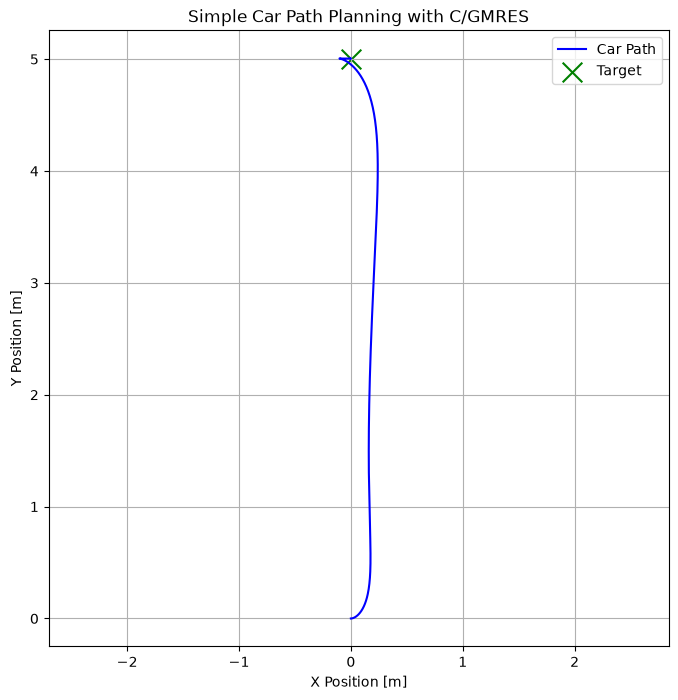

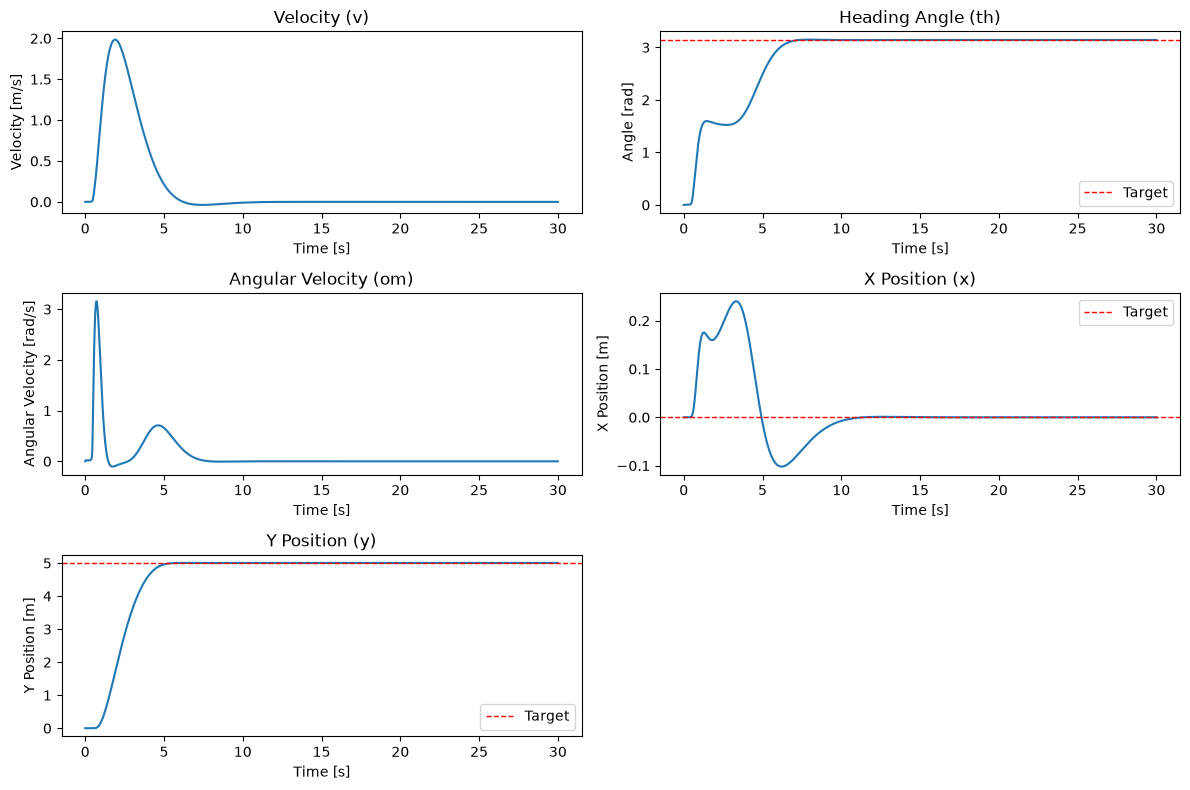

In [145]:
param1 = CarParams(
    epsilon=1e-3,
    zeta = 30,
    obstacles=np.array([
        [2.0, 0.0, 0.5, 0.0],
        [4.0, 2.0, 0.8, 0]],
         dtype=np.float64),
    target=np.array([np.radians(180.0), 0.0, 5.0], dtype=np.float64)
)

param1.m = 1
param1.I = 0.1
param1.Tf = 4.0
param1.Ta = 0.3
param1.dt = 0.01
 # qu, qta
param1.input_weights = np.array([10.0, 10.0], dtype=np.float64)
# eta_u, eta_tau
param1.barrier_weights = np.array([10.0, 10.0], dtype=np.float64)
 # u_max, tau_max
param1.input_limits = np.array([100.0, 100.0], dtype=np.float64)
# qvr, qthr, qomr, qxr, qyr
param1.q_running = np.array([5.0, 0.5, 0.1, 7.0, 7.0], dtype=np.float64)
# qvt, qtht, qomt, qxt, qyt
param1.q_terminal = np.array([1.0, 5.0, 1.0, 6.0, 6.0], dtype=np.float64)


states1, predicted_states1 = calc_simulation(param1, X0=np.array([0.0, 0.0, 0.0, 0.0, 0.0]), total_time=30.0)
show_result_in_map(states1, param1)
show_state_in_time(states1, param1)

姿勢の回転を行いながら、+y 方向に向かう。
面白い挙動として、Xの目標値を 0 としていることから、一度曲がるために直進した+x方向を 0 に戻している。<br>
そしてそのまま　- X方向へ移動し、また 0 へ戻すといった バックするような挙動になっている。

これは コ の字のような軌道を与えていないためと、ランニングコストの角度の評価を行っているためである。
現在位置が目標位置から大きく離れていると、位置誤差が大きくなり、目標位置へ近づけるために、姿勢を向ける力が働く。
逆に、位置誤差が小さい場合、角度誤差が相対的に大きくなるので、目標位置近くでは姿勢を目標へ合わせる力が強くなる 。

結果、これらのバランスでバックするような挙動になる。


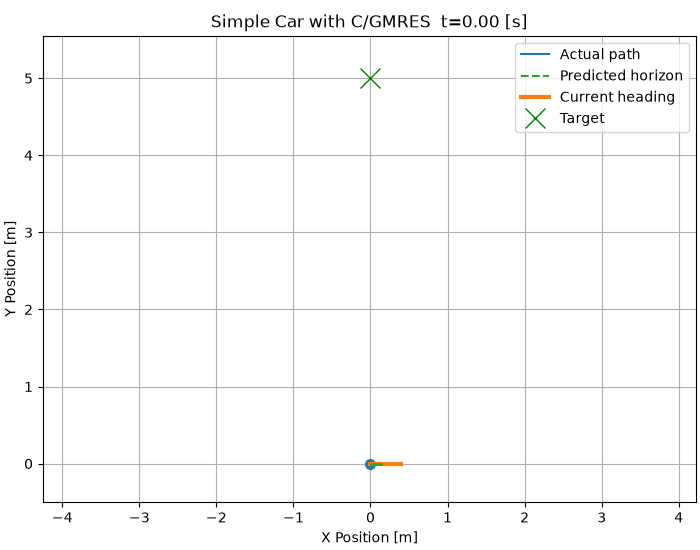

In [146]:
animation = create_car_animation(
    states1,
    predicted_states1,
    param1,
    frame_step=10,
    interval_ms=100,
    animation_start_time=0.0,
    animation_end_time=15.0,
    predicted_heading_step=3,
    view_aspect=1.4,
    gif_path="images/simple_car1.gif",
)

plt.close(animation._fig)

from IPython.display import Image, display

display(Image(filename="images/simple_car1.gif"))

C/GMRES mean time: 0.68 [ms]
C/GMRES max time: 6.96 [ms]
C/GMRES min time: 0.18 [ms]


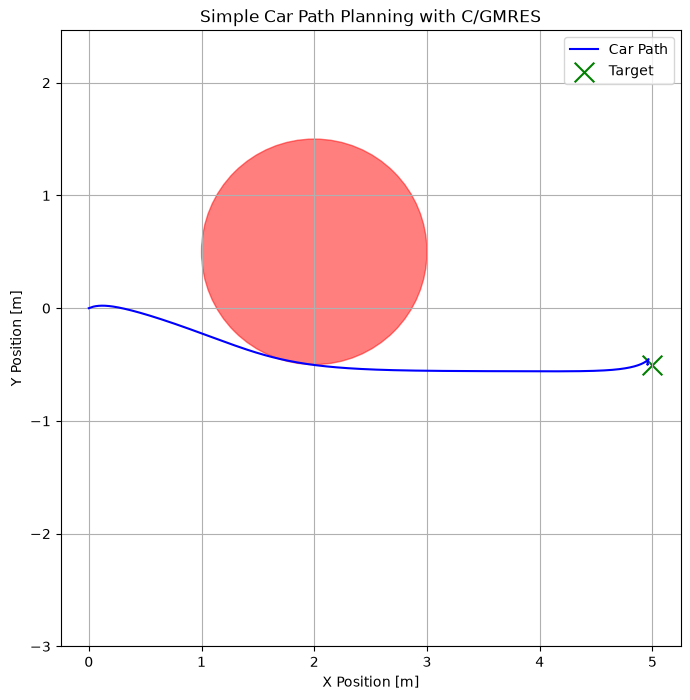

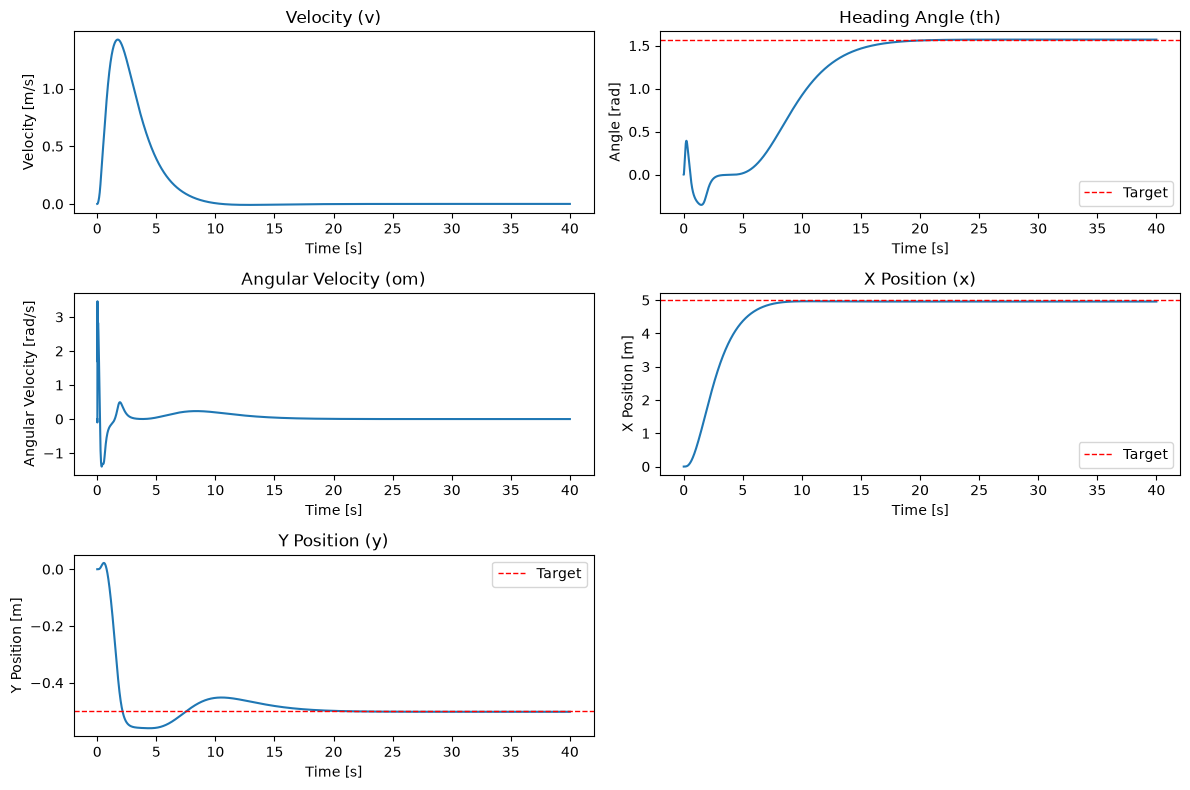

In [147]:
param2 = CarParams(
    epsilon=1e-3,
    obstacles=np.array([
        [2.0, 0.5, 1., 0.5],
        [4.0, 2.0, 0.8, 0]],
         dtype=np.float64),
    target=np.array([np.radians(90.0), 5.0, -0.5], dtype=np.float64)
)

param2.m = 1
param2.I = 0.01
param2.Tf = 5.5
param2.Ta = 0.7
param2.zeta = 30
param2.dt = 0.01
param2.input_weights = np.array([10.0, 10.0], dtype=np.float64)
param2.barrier_weights = np.array([10.0, 20.0], dtype=np.float64)
param2.input_limits = np.array([200.0, 100.0], dtype=np.float64)
# qvr, qthr, qomr, qxr, qyr
param2.q_running = np.array([15.0, 0.05, 0.75, 5.0, 5.0], dtype=np.float64)
# qvt, qtht, qomt, qxt, qyt
param2.q_terminal = np.array([1.1, 3.0, 1.1, 3.0, 4.0], dtype=np.float64)

# ランニング中のthetaはコストとして評価せず、x,yの位置のみをコストとして主に考える
# 終端でthetaのコストを考える。
# このようにすると、終端でtheta, x, y の目標値に対するズレが解消する

states2, predicted_states2 = calc_simulation(param2, X0=np.array([0.0, 0.0, 0.0, 0.0, 0.0]), total_time=40.0)
show_result_in_map(states2, param2)
show_state_in_time(states2, param2)

目標角度が+90deg と上を向いているため、Heading angle は最初に上を向くような挙動を示す。
これは角度目標値をステップ目標値のように与えているためである。

しかし、その後は、目標値へ移動するため先頭を目標値へ向ける必要があるため、もう一度姿勢を戻すような挙動になる。このような動作を行うために、ランニングコストでは $\theta, \omega$ に対するコストを極力小さくする必要がある。

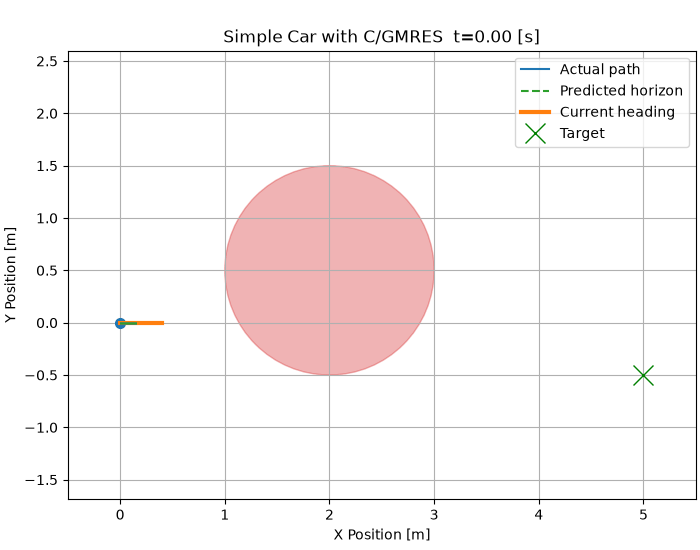

In [148]:
animation = create_car_animation(
    states2,
    predicted_states2,
    param2,
    frame_step=20,
    interval_ms=100,
    animation_start_time=0.0,
    animation_end_time=24.0,
    predicted_heading_step=3,
    view_aspect=1.4,
    gif_path="images/simple_car2.gif",
)

plt.close(animation._fig)

from IPython.display import Image, display

display(Image(filename="images/simple_car2.gif"))

# Step 応答として早く目標値に近づくようになるので、最初に姿勢を変更するような形になる。

その場で120deg 回転を行う挙動

C/GMRES mean time: 0.45 [ms]
C/GMRES max time: 3.72 [ms]
C/GMRES min time: 0.29 [ms]


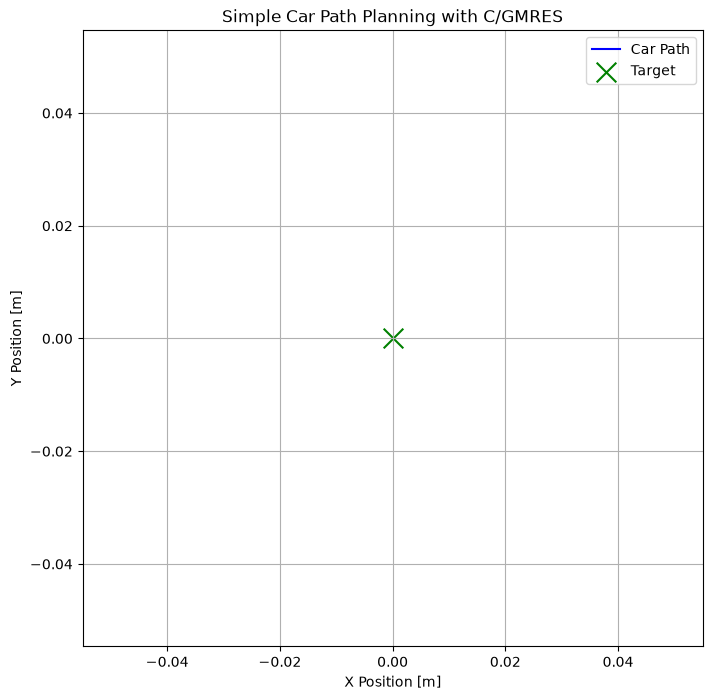

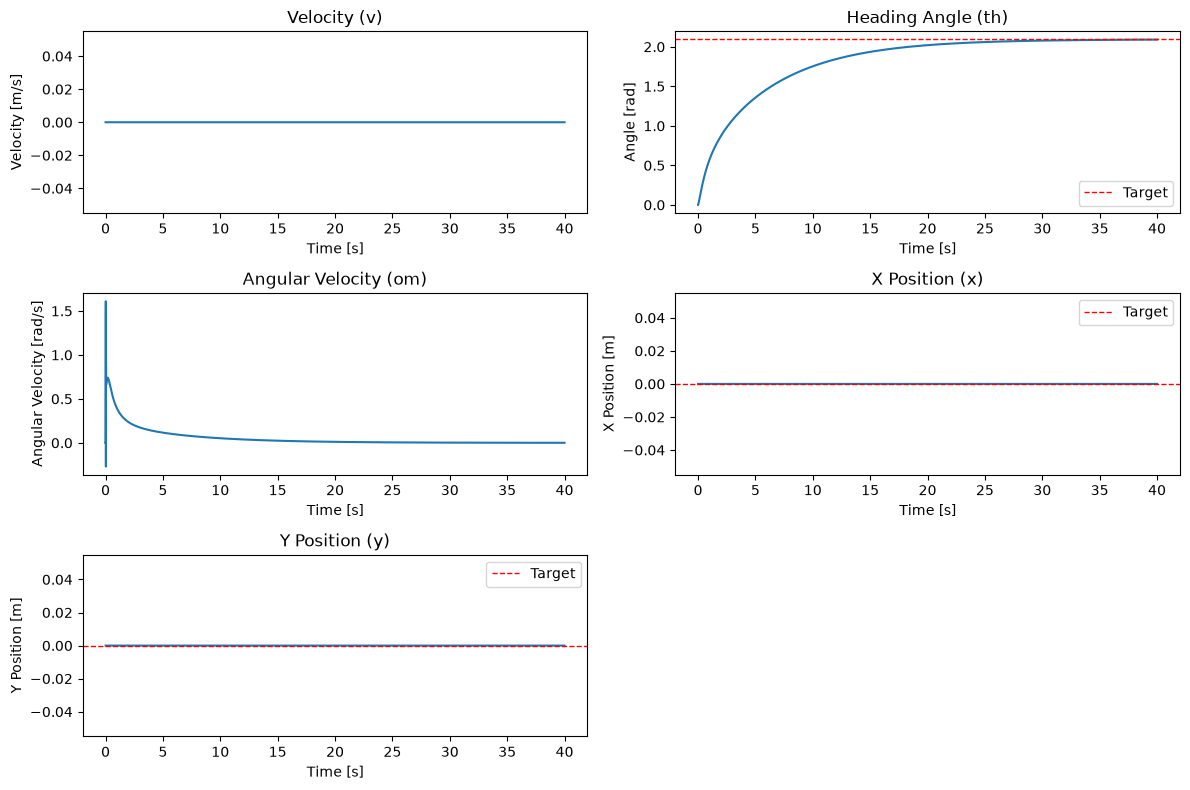

In [149]:
param3 = CarParams(
    epsilon=1e-3,
    obstacles=np.array([
        [2.0, 0.5, 1., 0.0],
        [4.0, 2.0, 0.8, 0]],
         dtype=np.float64),
    target=np.array([np.radians(120), 0.0, 0.0], dtype=np.float64)
)

param3.m = 1
param3.I = 0.01
param3.Tf = 5.5
param3.Ta = 0.7
param3.zeta = 30
param3.dt = 0.01
param3.input_weights = np.array([10.0, 10.0], dtype=np.float64)
param3.barrier_weights = np.array([10.0, 20.0], dtype=np.float64)
param3.input_limits = np.array([200.0, 100.0], dtype=np.float64)
# qvr, qthr, qomr, qxr, qyr
param3.q_running = np.array([1.0, 0.01, 6.75, 5.0, 5.0], dtype=np.float64)
# qvt, qtht, qomt, qxt, qyt
param3.q_terminal = np.array([1.1, 5.0, 0.0, 3.0, 4.0], dtype=np.float64)

states3, predicted_states3 = calc_simulation(param3, X0=np.array([0.0, 0.0, 0.0, 0.0, 0.0]), total_time=40.0)
show_result_in_map(states3, param3)
show_state_in_time(states3, param3)

これをステップ的な動作になる。特にAngular Velocityの立ち上がりが急峻になっている。

これは$v, \omega$ は制約をかけていないためである。

上限を設定することにより、急な立ち上がりを抑えることが出来ると考える。

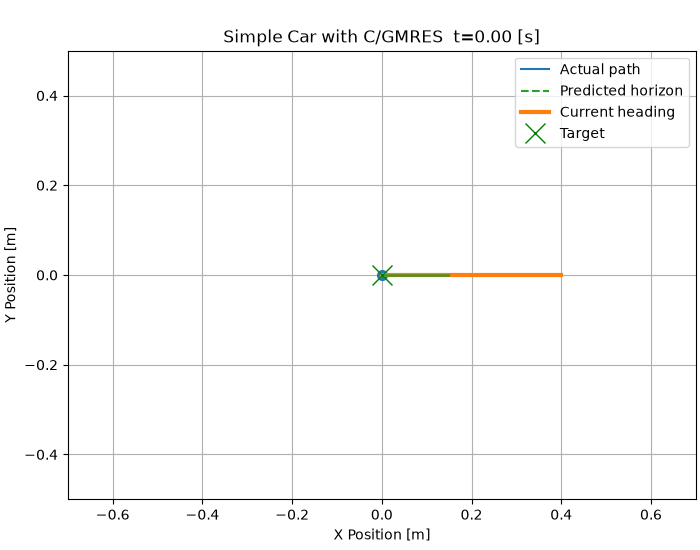

In [150]:
animation = create_car_animation(
    states3,
    predicted_states3,
    param3,
    frame_step=10,
    interval_ms=100,
    animation_start_time=0.0,
    animation_end_time=15.0,
    predicted_heading_step=3,
    view_aspect=1.4,
    gif_path="images/simple_car3.gif",
)

plt.close(animation._fig)

from IPython.display import Image, display

display(Image(filename="images/simple_car3.gif"))


障害物が2つあるパターン

C/GMRES mean time: 0.17 [ms]
C/GMRES max time: 0.81 [ms]
C/GMRES min time: 0.06 [ms]


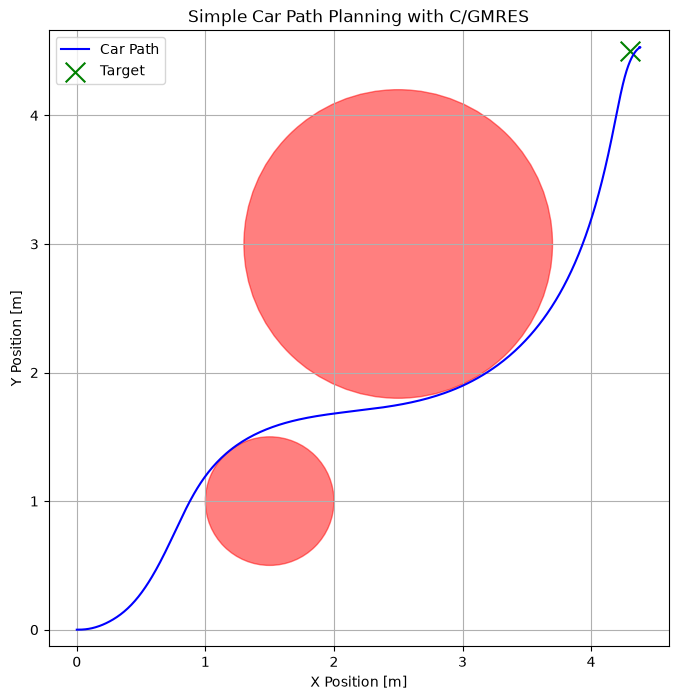

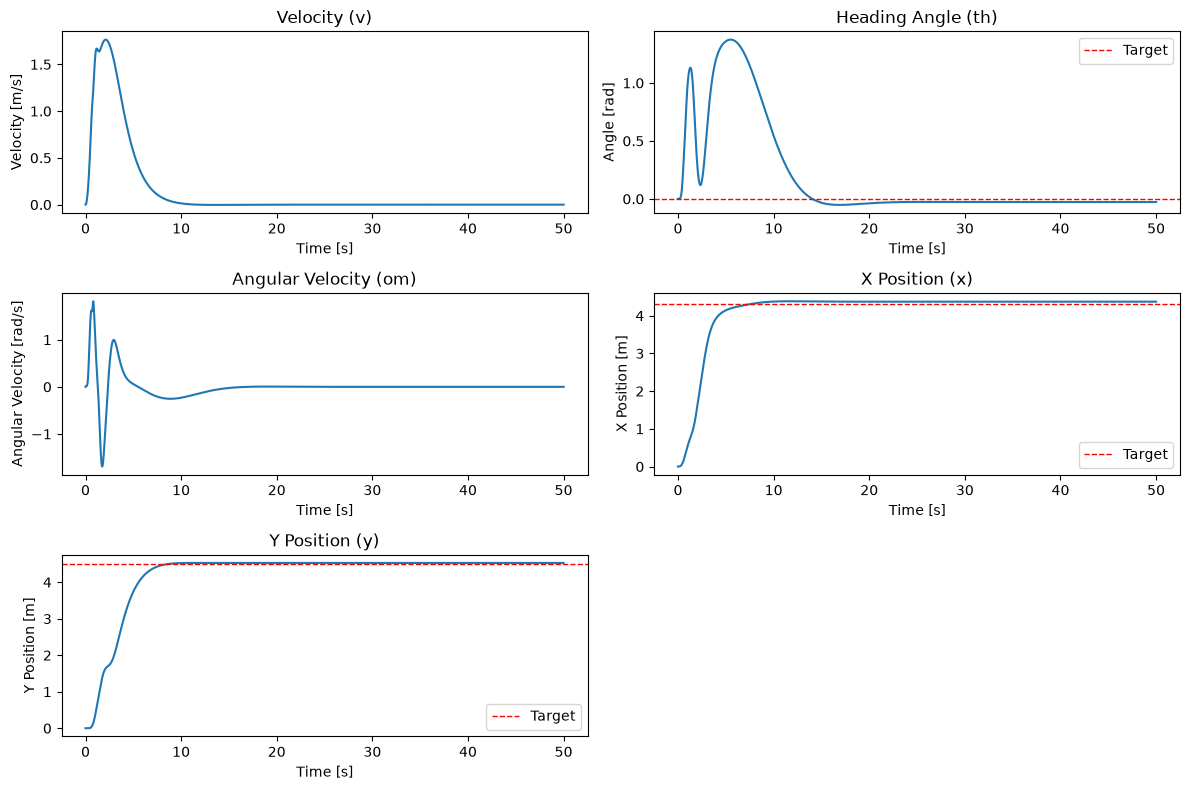

In [151]:
param4 = CarParams(
    epsilon=1e-3,
    zeta = 30,
    obstacles=np.array([
        [1.5, 1.0, 0.5, 3.0],
        [2.5, 3.0, 1.2, 2.0]],
         dtype=np.float64),
    target=np.array([np.radians(0.0), 4.3, 4.5], dtype=np.float64)
)

param4.m = 1
param4.I = 0.1
param4.Tf = 4.5
param4.Ta = 0.3
param4.dt = 0.01
 # qu, qta
param4.input_weights = np.array([10.0, 10.0], dtype=np.float64)
# eta_u, eta_tau
param4.barrier_weights = np.array([10.0, 10.0], dtype=np.float64)
 # u_max, tau_max
param4.input_limits = np.array([100.0, 100.0], dtype=np.float64)
# qvr, qthr, qomr, qxr, qyr
param4.q_running = np.array([15.0, 0.0, 0.0, 5.0, 5.0], dtype=np.float64)
# qvt, qtht, qomt, qxt, qyt
param4.q_terminal = np.array([2.0, 10.0, 2.0, 10.0, 10.0], dtype=np.float64)


states4, predicted_states4 = calc_simulation(param4, X0=np.array([0.0, 0.0, 0.0, 0.0, 0.0]), total_time=50.0)
show_result_in_map(states4, param4)
show_state_in_time(states4, param4)

Angular Velocityが急な動きを行うことで、二つの障害物を避けながら移動が出来る。

そのため、このcaseでは$\theta, \omega$ のランニングコストのゲインを極力小さくすることが必要になる。
また、このcaseでは障害物が多いため、確実に避けるために、障害物に対するゲインを大きくする必要があった。

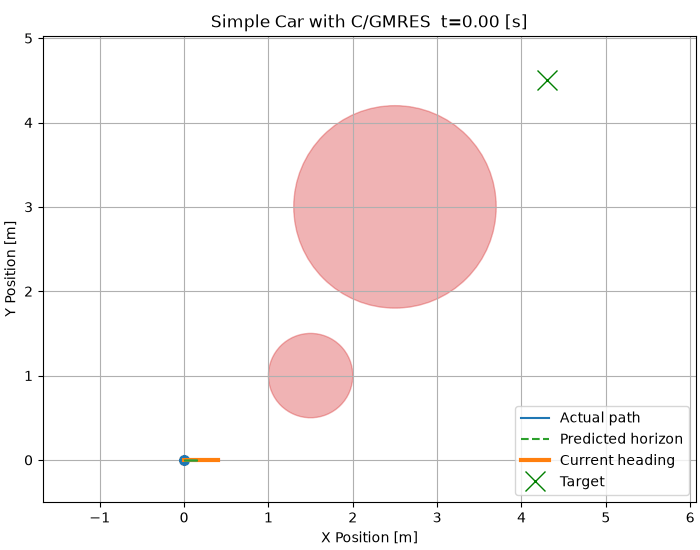

In [152]:
animation = create_car_animation(
    states4,
    predicted_states4,
    param4,
    frame_step=15,
    interval_ms=100,
    animation_start_time=0.0,
    animation_end_time=27.0,
    predicted_heading_step=3,
    view_aspect=1.4,
    gif_path="images/simple_car4.gif",
    label_loc="lower right"
)

plt.close(animation._fig)

from IPython.display import Image, display

display(Image(filename="images/simple_car4.gif"))


## 今後

今回見えた課題

- 同一のモデルを用いているが、状況により設定するゲインが異なる。
- 今の指令値の与え方でも良いか、ステップ的な応答が生じるため、何らかの方法で指令値を与えた方が良い。
- 制約は 台車の直方向速度 $v$ と回転方向角速度 $\omega$ についても行った方が良い。

上記内容を別のNoteで実施する。